In [5]:
#!pip install optuna

In [6]:
# 1. Importaciones
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.datasets import make_moons, make_circles, load_breast_cancer
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
import optuna
from xgboost import XGBClassifier
import warnings

from sklearn.base import clone
from copy import deepcopy
from sklearn.model_selection import StratifiedKFold
import time

from scipy.stats import f_oneway, friedmanchisquare
import matplotlib.pyplot as plt

import seaborn as sns
import gc
import tracemalloc
from joblib import Parallel, delayed


warnings.filterwarnings('ignore')

In [7]:
def encode_target(y):
    if isinstance(y[0], str):
        y = LabelEncoder().fit_transform(y)
    return y.astype(int)

# 2. Cargar Datasets adecuados
def load_datasets():
    datasets = []

    from sklearn.datasets import fetch_openml
    from sklearn.datasets import load_breast_cancer

    # Dataset: Banknote Authentication (Seguridad bancaria)
    X, y = fetch_openml(name="banknote-authentication", version=1, return_X_y=True, as_frame=False)
    datasets.append(("BanknoteAuth", X, y.astype(int)))

    # Dataset: Breast Cancer (WDBC)
    data = load_breast_cancer()
    datasets.append(("BreastCancer", data.data, data.target))

    # Dataset: Heart Disease Cleveland (UCI)
    X, y = fetch_openml(data_id=53, return_X_y=True, as_frame=True)
    X = X.select_dtypes(include='number').to_numpy()
    y = encode_target(y)
    datasets.append(("HeartDisease", X, y))

    # Dataset: Ionosphere (Radar UCI)
    X_df, y = fetch_openml(name="ionosphere", version=1, return_X_y=True, as_frame=True)
    y = encode_target(y)
    datasets.append(("Ionosphere", X_df.values.astype(float), y))

    # Dataset: KC2 Software Defect Prediction
    X, y = fetch_openml(name="kc2", version=1, return_X_y=True, as_frame=False)
    datasets.append(("KC2", X, y))

    # Dataset: QSAR Biodegradation (Biodegradabilidad química)
    X, y = fetch_openml(name="QSAR-Biodeg", version=1, return_X_y=True, as_frame=False)
    datasets.append(("QSARBiodeg", X, y.astype(int)))

    # Dataset: SpamBase (UCI)
    X, y = fetch_openml(name="spambase", version=1, return_X_y=True, as_frame=False)
    datasets.append(("SpamBase", X, y.astype(int)))

    return datasets

In [8]:
# 3. Definir funciones de entrenamiento para los métodos

def train_base(X_train, y_train, X_val=None, y_val=None):
    t_start = time.perf_counter()
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000
    return clf, train_time_ms, 0.0

def train_ccp(X_train, y_train, X_val, y_val):
    t_start = time.perf_counter()
    path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    best_score = 0
    best_alpha = 0
    for alpha in ccp_alphas:
        clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
        clf.fit(X_train, y_train)
        score = accuracy_score(y_val, clf.predict(X_val))
        if score > best_score:
            best_score = score
            best_alpha = alpha
    train_time_ms = (time.perf_counter() - t_start) * 1000
    t_prune = time.perf_counter()
    final_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
    final_model.fit(X_train, y_train)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000
    return final_model, train_time_ms, prune_time_ms

def train_ccp_modified_optimized(X_train, y_train, X_val, y_val, seed=42, n_trials=60):
    path = DecisionTreeClassifier(random_state=seed).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    n_total_features = X_train.shape[1]

    cached_trees = []
    for alpha in ccp_alphas:
        t = DecisionTreeClassifier(random_state=seed, ccp_alpha=alpha).fit(X_train, y_train)
        cached_trees.append({
            "alpha": alpha,
            "acc_train": accuracy_score(y_train, t.predict(X_train)),
            "acc_val": accuracy_score(y_val, t.predict(X_val)),
            "depth": t.get_depth(),
            "n_used": count_used_features(t),
        })

    def compute_modified_alpha(c, depth_penalty, feature_penalty_weight):
        return (c["alpha"] * (1 + abs(c["acc_train"] - c["acc_val"]))
                + depth_penalty * c["depth"]
                + feature_penalty_weight * (c["n_used"] / n_total_features))

    def eval_alpha(c, depth_penalty, feature_penalty_weight):
        modified_alpha = compute_modified_alpha(c, depth_penalty, feature_penalty_weight)
        clf = DecisionTreeClassifier(random_state=seed, ccp_alpha=modified_alpha).fit(X_train, y_train)
        return accuracy_score(y_val, clf.predict(X_val))

    def objective(trial):
        depth_penalty = trial.suggest_float("depth_penalty", 0.0001, 0.01)
        feature_penalty_weight = trial.suggest_float("feature_penalty_weight", 0.01, 0.2)
        scores = Parallel(n_jobs=6)(
            delayed(eval_alpha)(c, depth_penalty, feature_penalty_weight)
            for c in cached_trees
        )
        return max(scores)

    t_start = time.perf_counter()
    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, timeout=1000, n_jobs=1)
    best_params = study.best_params
    depth_penalty = best_params["depth_penalty"]
    feature_penalty_weight = best_params["feature_penalty_weight"]
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    scores = Parallel(n_jobs=6)(
        delayed(eval_alpha)(c, depth_penalty, feature_penalty_weight)
        for c in cached_trees
    )
    best_idx = int(np.argmax(scores))
    best_c = cached_trees[best_idx]
    best_modified_alpha = compute_modified_alpha(best_c, depth_penalty, feature_penalty_weight)
    best_model = DecisionTreeClassifier(random_state=seed, ccp_alpha=best_modified_alpha).fit(X_train, y_train)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000

    return best_model, train_time_ms, prune_time_ms

def train_ccp_ablation(X_train, y_train, X_val, y_val, depth_penalty='tune', feature_penalty_weight='tune', seed=42, n_trials=60):
    """
    Ablation wrapper for SR-CCP. Pass 0 to fix a penalty, 'tune' to let Optuna search.
    """
    path = DecisionTreeClassifier(random_state=seed).cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    n_total_features = X_train.shape[1]

    cached_trees = []
    for alpha in ccp_alphas:
        t = DecisionTreeClassifier(random_state=seed, ccp_alpha=alpha).fit(X_train, y_train)
        cached_trees.append({
            "alpha": alpha,
            "acc_train": accuracy_score(y_train, t.predict(X_train)),
            "acc_val": accuracy_score(y_val, t.predict(X_val)),
            "depth": t.get_depth(),
            "n_used": count_used_features(t),
        })

    def compute_modified_alpha(c, dp, fpw):
        return (c["alpha"] * (1 + abs(c["acc_train"] - c["acc_val"]))
                + dp * c["depth"]
                + fpw * (c["n_used"] / n_total_features))

    def eval_alpha(c, dp, fpw):
        modified_alpha = compute_modified_alpha(c, dp, fpw)
        clf = DecisionTreeClassifier(random_state=seed, ccp_alpha=modified_alpha).fit(X_train, y_train)
        return accuracy_score(y_val, clf.predict(X_val))

    t_start = time.perf_counter()

    tune_depth = depth_penalty == 'tune'
    tune_feat = feature_penalty_weight == 'tune'

    if tune_depth or tune_feat:
        def objective(trial):
            dp = trial.suggest_float("depth_penalty", 0.0001, 0.01) if tune_depth else depth_penalty
            fpw = trial.suggest_float("feature_penalty_weight", 0.01, 0.2) if tune_feat else feature_penalty_weight
            scores = Parallel(n_jobs=6)(
                delayed(eval_alpha)(c, dp, fpw) for c in cached_trees
            )
            return max(scores)

        sampler = optuna.samplers.TPESampler(seed=seed)
        study = optuna.create_study(direction="maximize", sampler=sampler)
        study.optimize(objective, n_trials=n_trials, timeout=1000, n_jobs=1)
        best_params = study.best_params
        final_dp = best_params.get("depth_penalty", depth_penalty) if tune_depth else depth_penalty
        final_fpw = best_params.get("feature_penalty_weight", feature_penalty_weight) if tune_feat else feature_penalty_weight
    else:
        final_dp = depth_penalty
        final_fpw = feature_penalty_weight

    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    scores = Parallel(n_jobs=6)(
        delayed(eval_alpha)(c, final_dp, final_fpw) for c in cached_trees
    )
    best_idx = int(np.argmax(scores))
    best_c = cached_trees[best_idx]
    best_modified_alpha = compute_modified_alpha(best_c, final_dp, final_fpw)
    best_model = DecisionTreeClassifier(random_state=seed, ccp_alpha=best_modified_alpha).fit(X_train, y_train)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000

    return best_model, train_time_ms, prune_time_ms


def train_rep(X_train, y_train, X_val, y_val):
    """
    Entrena un árbol y aplica Reduced Error Pruning con poda lógica.
    Retorna un modelo DecisionTreeClassifier podado.
    """
    t_start = time.perf_counter()
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    tree_pruned = deepcopy(tree)
    classes_in_tree = tree_pruned.classes_

    def apply_tree_mask(clf, X, node_id):
        indicator = clf.decision_path(X)
        return indicator[:, node_id].toarray().flatten().astype(bool)

    def prune_node(node_id):
        left = tree_pruned.tree_.children_left[node_id]
        right = tree_pruned.tree_.children_right[node_id]
        if left == -1 and right == -1:
            return
        if left != -1:
            prune_node(left)
        if right != -1:
            prune_node(right)
        backup = (
            tree_pruned.tree_.children_left[node_id],
            tree_pruned.tree_.children_right[node_id],
            tree_pruned.tree_.feature[node_id],
            tree_pruned.tree_.threshold[node_id],
            tree_pruned.tree_.value[node_id].copy()
        )
        tree_pruned.tree_.children_left[node_id] = -1
        tree_pruned.tree_.children_right[node_id] = -1
        tree_pruned.tree_.feature[node_id] = -2
        tree_pruned.tree_.threshold[node_id] = -2.0
        mask = apply_tree_mask(tree_pruned, X_val, node_id)
        if np.sum(mask) == 0:
            revert_pruning(node_id, backup)
            return
        y_node = y_val[mask]
        unique_classes, counts = np.unique(y_node, return_counts=True)
        majority_label = unique_classes[np.argmax(counts)]
        majority_index = np.where(classes_in_tree == majority_label)[0][0]
        new_value = np.zeros((1, len(classes_in_tree)))
        new_value[0, majority_index] = counts.max()
        tree_pruned.tree_.value[node_id] = new_value
        acc_before = np.mean(tree.predict(X_val) == y_val)
        acc_after = np.mean(tree_pruned.predict(X_val) == y_val)
        if acc_after < acc_before:
            revert_pruning(node_id, backup)

    def revert_pruning(node_id, backup):
        (cl, cr, f, t, v) = backup
        tree_pruned.tree_.children_left[node_id] = cl
        tree_pruned.tree_.children_right[node_id] = cr
        tree_pruned.tree_.feature[node_id] = f
        tree_pruned.tree_.threshold[node_id] = t
        tree_pruned.tree_.value[node_id] = v

    prune_node(0)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000
    return tree_pruned, train_time_ms, prune_time_ms

def train_depth_pruning(X_train, y_train, X_val=None, y_val=None, max_depth=5):
    t_start = time.perf_counter()
    clf = DecisionTreeClassifier(random_state=42, max_depth=max_depth)
    clf.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000
    return clf, train_time_ms, 0.0
from sklearn.tree import DecisionTreeClassifier
from copy import deepcopy
import numpy as np

def train_mep(X_train, y_train, X_val, y_val):
    """
    Entrena un árbol de decisión completo y aplica Minimum Error Pruning (MEP),
    podando nodos cuando el error estimado como hoja es menor que como subárbol.

    Retorna un árbol podado (DecisionTreeClassifier).
    """
    t_start = time.perf_counter()
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    tree = deepcopy(clf)
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    n_nodes = tree.tree_.node_count
    classes = tree.classes_
    n_classes = len(classes)

    def apply_tree_mask(clf, X, node_id):
        indicator = clf.decision_path(X)
        return indicator[:, node_id].toarray().flatten().astype(bool)

    def prune_node(node_id):
        left, right = cl[node_id], cr[node_id]
        if left == -1 and right == -1:
            return
        if left != -1:
            prune_node(left)
        if right != -1:
            prune_node(right)
        backup = (
            cl[node_id], cr[node_id],
            tree.tree_.feature[node_id],
            tree.tree_.threshold[node_id],
            tree.tree_.value[node_id].copy()
        )
        cl[node_id] = cr[node_id] = -1
        tree.tree_.feature[node_id] = -2
        tree.tree_.threshold[node_id] = -2.0
        mask = apply_tree_mask(tree, X_val, node_id)
        if np.sum(mask) == 0:
            revert(node_id, backup)
            return
        y_node = y_val[mask]
        values = np.zeros((1, n_classes))
        for c in np.unique(y_node):
            if c in classes:
                idx = np.where(classes == c)[0][0]
                values[0, idx] = np.sum(y_node == c)
        tree.tree_.value[node_id] = values
        y_true = y_val[mask]
        y_pred_full = clf.predict(X_val[mask])
        y_pred_pruned = tree.predict(X_val[mask])
        err_before = np.sum(y_pred_full != y_true)
        err_after = np.sum(y_pred_pruned != y_true)
        if err_after > err_before:
            revert(node_id, backup)

    def revert(node_id, backup):
        cl[node_id], cr[node_id], f, t, v = backup
        tree.tree_.feature[node_id] = f
        tree.tree_.threshold[node_id] = t
        tree.tree_.value[node_id] = v

    prune_node(0)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000
    return tree, train_time_ms, prune_time_ms

class RelabeledXGBClassifier:
    """
    Envoltorio picklable que remapea las predicciones de un XGBClassifier
    entrenado sobre etiquetas 0..K-1 de vuelta a las etiquetas originales del
    dataset (necesario porque algunos datasets cargados en load_datasets, p.ej.
    KC2, no pasan por encode_target y pueden traer clases no contiguas como {1, 2}).
    """
    def __init__(self, model, classes):
        self.model = model
        self.classes_ = np.asarray(classes)

    def predict(self, X):
        encoded_pred = self.model.predict(X)
        return self.classes_[encoded_pred.astype(int)]

    def get_booster(self):
        return self.model.get_booster()


def train_xgboost(X_train, y_train, X_val, y_val, seed=42, n_trials=40):
    """
    Entrena un XGBClassifier cuyo pruning esta gobernado por gamma/reg_alpha/reg_lambda
    y early stopping. Los hiperparametros se optimizan con Optuna, de forma analoga a la
    busqueda de depth_penalty/feature_penalty_weight en train_ccp_modified_optimized.
    """
    classes, y_train_enc = np.unique(y_train, return_inverse=True)
    label_to_idx = {label: idx for idx, label in enumerate(classes)}
    y_val_enc = np.array([label_to_idx[label] for label in y_val])
    n_classes = len(classes)
    objective_name = "binary:logistic" if n_classes == 2 else "multi:softmax"

    def build_model(params):
        kwargs = dict(
            objective=objective_name,
            n_estimators=300,
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            gamma=params["gamma"],
            reg_alpha=params["reg_alpha"],
            reg_lambda=params["reg_lambda"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            random_state=seed,
            n_jobs=1,
            verbosity=0,
            eval_metric="logloss" if n_classes == 2 else "mlogloss",
            early_stopping_rounds=20,
        )
        if n_classes > 2:
            kwargs["num_class"] = n_classes
        return XGBClassifier(**kwargs)

    def objective(trial):
        params = {
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "gamma": trial.suggest_float("gamma", 1e-4, 5.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        }
        model = build_model(params)
        model.fit(X_train, y_train_enc, eval_set=[(X_val, y_val_enc)], verbose=False)
        return accuracy_score(y_val_enc, model.predict(X_val))

    t_start = time.perf_counter()
    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, timeout=1000, n_jobs=1)
    best_params = study.best_params
    train_time_ms = (time.perf_counter() - t_start) * 1000

    t_prune = time.perf_counter()
    best_model_raw = build_model(best_params)
    best_model_raw.fit(X_train, y_train_enc, eval_set=[(X_val, y_val_enc)], verbose=False)
    best_model = RelabeledXGBClassifier(best_model_raw, classes)
    prune_time_ms = (time.perf_counter() - t_prune) * 1000

    return best_model, train_time_ms, prune_time_ms

def count_reachable_nodes_and_leaves(tree):
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    def count(node):
        if node == -1:
            return (0, 0)
        if cl[node] == -1 and cr[node] == -1:
            return (1, 1)
        ln, ll = count(cl[node])
        rn, rl = count(cr[node])
        return (1 + ln + rn, ll + rl)
    return count(0)

def count_real_depth(tree):
    cl, cr = tree.tree_.children_left, tree.tree_.children_right
    def depth(node):
        if node == -1:
            return 0
        if cl[node] == -1 and cr[node] == -1:
            return 1
        return 1 + max(depth(cl[node]), depth(cr[node]))
    return depth(0)

def count_used_features(model):
    """Returns the number of unique features used in decision splits."""
    used_features = model.tree_.feature
    return len(set(used_features[used_features >= 0]))

def get_tree_structure_metrics(model):
    """
    Metricas estructurales (depth, nodes, leaves, n_features_used) validas tanto
    para un DecisionTreeClassifier unico como para un ensamble boosted (XGBClassifier).
    Para ensambles, nodes/leaves se agregan sobre todos los arboles y depth es el
    promedio de profundidad por arbol.
    """
    if hasattr(model, "get_booster"):
        trees_df = model.get_booster().trees_to_dataframe()
        is_leaf = trees_df["Feature"] == "Leaf"
        n_nodes = len(trees_df)
        n_leaves = int(is_leaf.sum())
        n_features_used = trees_df.loc[~is_leaf, "Feature"].nunique()

        depths = []
        for _, tree_df in trees_df.groupby("Tree"):
            nodes_by_id = tree_df.set_index("ID")
            root_id = tree_df.loc[tree_df["Node"] == 0, "ID"].iloc[0]
            node_depth = {}

            def visit(node_id, d):
                node_depth[node_id] = d
                row = nodes_by_id.loc[node_id]
                for child_id in (row.get("Yes"), row.get("No")):
                    if isinstance(child_id, str) and child_id in nodes_by_id.index:
                        visit(child_id, d + 1)

            visit(root_id, 0)
            depths.append(max(node_depth.values()))

        depth = float(np.mean(depths)) if depths else 0.0
        return depth, n_nodes, n_leaves, n_features_used

    depth = count_real_depth(model)
    n_nodes, n_leaves = count_reachable_nodes_and_leaves(model)
    n_features_used = count_used_features(model)
    return depth, n_nodes, n_leaves, n_features_used

def evaluate(model, X_test, y_test, n_runs=10000, discard_first=True, use_median=True):
    """
    Evalúa el modelo con múltiples ejecuciones para reducir la varianza en tiempo de inferencia.
    Also measures model memory usage.
    """
    # Measure memory usage by serializing the model
    import io, pickle
    buffer = io.BytesIO()
    pickle.dump(model, buffer)
    memory_usage_kb = buffer.tell() / 1024

    times = []
    y_pred = None

    gc.disable()

    for _ in range(n_runs + 1 if discard_first else n_runs):
        start_time = time.perf_counter()
        y_pred = model.predict(X_test)
        elapsed = time.perf_counter() - start_time
        times.append(elapsed)

    gc.enable()

    if discard_first:
        times = times[1:]

    times_ms = np.array(times) * 1000
    inference_std = times_ms.std()

    if use_median:
        inference_time = np.median(times_ms)
    else:
        inference_time = times_ms.mean()

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    depth, n_nodes, n_leaves, n_features_used = get_tree_structure_metrics(model)

    return accuracy, f1, balanced_acc, depth, n_nodes, n_leaves, inference_time, inference_std, n_features_used, memory_usage_kb

from sklearn.feature_selection import SelectKBest, f_classif

def cross_validate_models(X, y, model_fns, k=5):
    """
    cross_validate_models: Validación cruzada con entrenamiento y evaluación por modelo.
    Retorna:
      means    : dict modelo -> media de cada métrica (10 valores)
      stds     : dict modelo -> desviación estándar de cada métrica
      train_times : dict modelo -> media de tiempo de entrenamiento (ms)
      train_stds  : dict modelo -> desviación estándar del tiempo de entrenamiento (ms)
      prune_times : dict modelo -> media de tiempo de poda (ms)
      prune_stds  : dict modelo -> desviación estándar del tiempo de poda (ms)
      peak_memory_mean : dict modelo -> media de memoria pico (KB)
      peak_memory_std  : dict modelo -> desviación estándar de memoria pico (KB)
    """
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    results = {name: [] for name in model_fns}
    train_times = {name: [] for name in model_fns}
    prune_times = {name: [] for name in model_fns}
    peak_memories = {name: [] for name in model_fns}

    for fold_idx, (train_val_idx, test_idx) in enumerate(kf.split(X, y)):
        X_train_val, X_test = X[train_val_idx], X[test_idx]
        y_train_val, y_test = y[train_val_idx], y[test_idx]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
        )

        print(f"\n--- Fold {fold_idx+1}/{k} ---")
        print(f"  Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

        for name, fn in model_fns.items():
            print(f"  Training {name}...")
            tracemalloc.start()
            model, t_ms, p_ms = fn(X_train, y_train, X_val, y_val)
            _, peak_bytes = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            peak_memory_kb = peak_bytes / 1024
            metrics = evaluate(model, X_test, y_test)
            results[name].append(metrics)
            train_times[name].append(t_ms)
            prune_times[name].append(p_ms)
            peak_memories[name].append(peak_memory_kb)
            print(f"    => {metrics[:5]}")

    means = {name: np.mean(vals, axis=0) for name, vals in results.items()}
    stds  = {name: np.std(vals, axis=0)  for name, vals in results.items()}
    train_time_mean = {name: np.mean(times) for name, times in train_times.items()}
    train_time_std  = {name: np.std(times)  for name, times in train_times.items()}
    prune_time_mean = {name: np.mean(times) for name, times in prune_times.items()}
    prune_time_std  = {name: np.std(times)  for name, times in prune_times.items()}
    peak_memory_mean = {name: np.mean(mems) for name, mems in peak_memories.items()}
    peak_memory_std  = {name: np.std(mems)  for name, mems in peak_memories.items()}

    return means, stds, train_time_mean, train_time_std, prune_time_mean, prune_time_std, peak_memory_mean, peak_memory_std

# ======================= EVALUACIÓN POR DATASET ===========================
datasets = load_datasets()
results = []

for name, X, y in datasets:
    print(f"Procesando {name}...")

    model_fns = {
        "Base":             train_base,
        "CCP":              train_ccp,
        "CCP_Modified":     train_ccp_modified_optimized,
        "REP":              train_rep,
        "MEP":              train_mep,
        "DepthPruning":     train_depth_pruning,
        "XGBoost":          train_xgboost
    }

    means, stds, train_time_mean, train_time_std, prune_time_mean, prune_time_std, peak_memory_mean, peak_memory_std = cross_validate_models(X, y, model_fns, k=5)

    for method in model_fns:
        m = means[method]
        acc, f1, balanced_acc, depth, nodes, leaves, inference_time, inference_std, n_features_used, memory_kb = m
        results.append([
            name, method, acc, f1, balanced_acc,
            depth, nodes, leaves,
            inference_time, inference_std, n_features_used,
            train_time_mean[method], prune_time_mean[method], memory_kb, peak_memory_mean[method]
        ])


Procesando BanknoteAuth...

--- Fold 1/5 ---
  Train: 877, Validation: 220, Test: 275
  Training Base...
    => (0.9781818181818182, 0.9778630460448643, 0.9770706096646309, 9, 49)
  Training CCP...


[I 2026-07-05 18:35:08,395] A new study created in memory with name: no-name-ef3e2f91-6ff7-4d3c-8a17-b5199bd5c8eb


    => (0.9781818181818182, 0.9778630460448643, 0.9770706096646309, 9, 49)
  Training CCP_Modified...


[I 2026-07-05 18:35:09,122] Trial 0 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.003807947176588889, 'feature_penalty_weight': 0.19063571821788408}. Best is trial 0 with value: 0.8636363636363636.
[I 2026-07-05 18:35:09,157] Trial 1 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.007346740023932911, 'feature_penalty_weight': 0.12374511199743694}. Best is trial 0 with value: 0.8636363636363636.
[I 2026-07-05 18:35:09,182] Trial 2 finished with value: 0.8954545454545455 and parameters: {'depth_penalty': 0.0016445845403801217, 'feature_penalty_weight': 0.039638958863878505}. Best is trial 2 with value: 0.8954545454545455.
[I 2026-07-05 18:35:09,204] Trial 3 finished with value: 0.8636363636363636 and parameters: {'depth_penalty': 0.0006750277604651748, 'feature_penalty_weight': 0.1745734676972377}. Best is trial 2 with value: 0.8954545454545455.
[I 2026-07-05 18:35:09,226] Trial 4 finished with value: 0.8636363636363636 and parame

    => (0.9345454545454546, 0.9337029893924783, 0.9337029893924783, 4, 9)
  Training REP...
    => (0.9527272727272728, 0.9519934469376519, 0.9508732454730526, 6, 23)
  Training MEP...
    => (0.9527272727272728, 0.9519934469376519, 0.9508732454730526, 6, 23)
  Training DepthPruning...


...

    => (0.8576086956521739, 0.8453521600268952, 0.8355561496267252, 4, 9)
  Training REP...
    => (0.8945652173913043, 0.8890567210567211, 0.8873690568130062, 7, 27)
  Training MEP...
    => (0.9, 0.8950396825396825, 0.8942751341610725, 13, 49)
  Training DepthPruning...


[I 2026-07-05 18:47:33,102] A new study created in memory with name: no-name-af82da6a-6374-4cd8-b182-be9316e8af0f
[I 2026-07-05 18:47:33,214] Trial 0 finished with value: 0.9606512890094979 and parameters: {'max_depth': 4, 'learning_rate': 0.2536999076681772, 'gamma': 0.27518044962720845, 'reg_alpha': 0.09846738873614563, 'reg_lambda': 0.0006026889128682511, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797}. Best is trial 0 with value: 0.9606512890094979.


    => (0.9032608695652173, 0.8973367487546375, 0.8925968831065962, 6, 53)
  Training XGBoost...


[I 2026-07-05 18:47:33,738] Trial 1 finished with value: 0.966078697421981 and parameters: {'max_depth': 8, 'learning_rate': 0.07725378389307355, 'gamma': 0.21242802137208885, 'reg_alpha': 0.00012674255898937226, 'reg_lambda': 7.072114131472227, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105}. Best is trial 1 with value: 0.966078697421981.
[I 2026-07-05 18:47:34,015] Trial 2 finished with value: 0.9579375848032564 and parameters: {'max_depth': 3, 'learning_rate': 0.018659959624904916, 'gamma': 0.0026892128247368906, 'reg_alpha': 0.042051564509138675, 'reg_lambda': 0.01444525102276306, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8447411578889518}. Best is trial 1 with value: 0.966078697421981.
[I 2026-07-05 18:47:34,219] Trial 3 finished with value: 0.9497964721845319 and parameters: {'max_depth': 2, 'learning_rate': 0.027010527749605478, 'gamma': 0.005266514841107984, 'reg_alpha': 0.019069966103000432, 'reg_lambda': 0.8431013932082461, 'subsample': 0

    => (0.9445652173913044, 0.9414254879024657, 0.9378056991227549, 6.100671140939597, 4195)


In [9]:
"""
# ====================== ABLATION STUDY: SR-CCP COMPONENTS (Obs 14) ======================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

configs = {
    'SR-CCP (full)':     {'depth_penalty': 'tune', 'feature_penalty_weight': 'tune'},
    'No Depth':          {'depth_penalty': 0,      'feature_penalty_weight': 'tune'},
    'No Feature':        {'depth_penalty': 'tune', 'feature_penalty_weight': 0},
    'No Penalties':      {'depth_penalty': 0,      'feature_penalty_weight': 0},
}

ablation_datasets = load_datasets()
ablation_results = []

for ds_name, X, y in ablation_datasets:
    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name} (n={len(X)}, d={X.shape[1]})")
    print(f"{'='*60}")

    for cfg_name, cfg_params in configs.items():
        print(f"  {cfg_name}...")
        model_fns_abl = {
            cfg_name: lambda X_tr, y_tr, X_v, y_v, dp=cfg_params['depth_penalty'], fpw=cfg_params['feature_penalty_weight']: \
                train_ccp_ablation(X_tr, y_tr, X_v, y_v, depth_penalty=dp, feature_penalty_weight=fpw)
        }
        means, stds, _, _, _, _, _, _ = cross_validate_models(X, y, model_fns_abl, k=5)
        m = means[cfg_name]
        acc, f1, balanced_acc, depth, nodes, leaves, inference_time, inference_std, n_features_used, memory_kb = m
        ablation_results.append({
            'Dataset': ds_name, 'Config': cfg_name,
            'Accuracy': acc, 'F1': f1, 'Balanced_Acc': balanced_acc,
            'Depth': depth, 'Nodes': nodes, 'Leaves': leaves,
            'n_Features': n_features_used
        })

ablation_df = pd.DataFrame(ablation_results)

# --- Summary table ---
print("\n" + "="*80)
ablation_df.to_csv('ablation/ablation_results.csv', index=False)
print("ABLATION SUMMARY (mean across datasets)")
print("="*80)
summary = ablation_df.groupby('Config')[['Accuracy', 'Depth', 'Nodes', 'Leaves', 'n_Features']].mean()
print(summary.round(4))

# --- Chart 1: Accuracy per config per dataset ---
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=ablation_df, x='Dataset', y='Accuracy', hue='Config', palette='Set2', edgecolor='black')
plt.title('Ablation Study: Accuracy by SR-CCP Configuration', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('ablation/ablation_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Chart 2: Tree complexity (Depth, Nodes, n_Features) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col, title in zip(axes, ['Depth', 'Nodes', 'n_Features'], ['Tree Depth', 'Number of Nodes', 'Features Used']):
    sns.barplot(data=ablation_df, x='Dataset', y=col, hue='Config', palette='Set2', edgecolor='black', ax=ax)
    ax.set_title(f'Ablation: {title}', fontsize=13)
    ax.set_ylabel(title, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if ax != axes[0]:
        ax.get_legend().remove()
axes[0].legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('ablation/ablation_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Delta from full SR-CCP ---
print("\n" + "="*80)
print("DELTA vs SR-CCP (full)")
print("="*80)
full = ablation_df[ablation_df['Config'] == 'SR-CCP (full)'].set_index('Dataset')
for cfg in ['No Depth', 'No Feature', 'No Penalties']:
    partial = ablation_df[ablation_df['Config'] == cfg].set_index('Dataset')
    delta_acc = partial['Accuracy'] - full['Accuracy']
    delta_feat = partial['n_Features'] - full['n_Features']
    print(f"\n{cfg} vs SR-CCP:")
    print(f"  Mean ΔAccuracy: {delta_acc.mean():.4f}  Mean ΔFeatures: {delta_feat.mean():.1f}")
"""


'\n# ====================== ABLATION STUDY: SR-CCP COMPONENTS (Obs 14) ======================\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\nconfigs = {\n    \'SR-CCP (full)\':     {\'depth_penalty\': \'tune\', \'feature_penalty_weight\': \'tune\'},\n    \'No Depth\':          {\'depth_penalty\': 0,      \'feature_penalty_weight\': \'tune\'},\n    \'No Feature\':        {\'depth_penalty\': \'tune\', \'feature_penalty_weight\': 0},\n    \'No Penalties\':      {\'depth_penalty\': 0,      \'feature_penalty_weight\': 0},\n}\n\nablation_datasets = load_datasets()\nablation_results = []\n\nfor ds_name, X, y in ablation_datasets:\n    print(f"\n{\'=\'*60}")\n    print(f"Dataset: {ds_name} (n={len(X)}, d={X.shape[1]})")\n    print(f"{\'=\'*60}")\n\n    for cfg_name, cfg_params in configs.items():\n        print(f"  {cfg_name}...")\n        model_fns_abl = {\n            cfg_name: lambda X_tr, y_tr, X_v, y_v, dp=cfg_params[\'depth_penalty\'], fpw=cfg_params[\'fe

In [10]:
"""
# ======================= ABLATION STUDY: n_trials (ALL DATASETS) ===========================
from functools import partial

def train_ccp_modified_n(X_train, y_train, X_val, y_val, n_trials=60):
    return train_ccp_modified_optimized(X_train, y_train, X_val, y_val,
                                         seed=42, n_trials=n_trials)

ablation_datasets = load_datasets()
trials_list = [5, 10, 15, 20, 30, 60]
all_ablation_results = []

for ds_name, X, y in ablation_datasets:
    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name} (n={len(X)}, d={X.shape[1]})")
    print(f"{'='*60}")

    # Benchmark CCP estandar como referencia
    model_fns_ccp = {"CCP": train_ccp}
    t_ccp = time.perf_counter()
    cross_validate_models(X, y, model_fns_ccp, k=3)
    ccp_time = (time.perf_counter() - t_ccp) * 1000

    for n_t in trials_list:
        print(f"  n_trials={n_t}...")
        fn = partial(train_ccp_modified_n, n_trials=n_t)
        model_fns_abl = {
            "CCP": train_ccp,
            f"CCP_Mod({n_t})": fn,
        }
        t0 = time.perf_counter()
        means, stds, _, _, _, _, _, _ = cross_validate_models(X, y, model_fns_abl, k=3)
        total_ms = (time.perf_counter() - t0) * 1000

        m = means[f"CCP_Mod({n_t})"]
        m_ccp = means["CCP"]
        all_ablation_results.append({
            "dataset": ds_name,
            "n_trials": n_t,
            "accuracy": m[0],
            "f1": m[1],
            "balanced_acc": m[2],
            "total_time_ms": total_ms,
            "ccp_accuracy": m_ccp[0],
            "ccp_time_ms": ccp_time,
            "delta_acc": m[0] - m_ccp[0],
        })
        print(f"    Acc={m[0]:.4f}, CCP_Acc={m_ccp[0]:.4f}, dAcc={m[0]-m_ccp[0]:+.4f}, Time={total_ms:.0f}ms")

# =================== TABLA CONSOLIDADA ===================
print("\n" + "="*90)
print("ABLATION TABLE: n_trials vs Accuracy vs Time (ALL DATASETS)")
print("="*90)
print(f"{'Dataset':>16} {'n_trials':>8} {'Accuracy':>10} {'CCP_Acc':>10} {'dAcc':>8} {'Time(ms)':>10} {'CCP_Time':>10} {'Factor':>8}")
print("-"*90)
for r in all_ablation_results:
    factor = r["total_time_ms"] / r["ccp_time_ms"] if r["ccp_time_ms"] > 0 else 0
    print(f"{r['dataset']:>16} {r['n_trials']:>8} {r['accuracy']:>10.4f} {r['ccp_accuracy']:>10.4f} {r['delta_acc']:>+8.4f} {r['total_time_ms']:>10.0f} {r['ccp_time_ms']:>10.0f} {factor:>7.1f}x")

# =================== RESUMEN POR n_trials ===================
print("\n" + "="*70)
print("PROMEDIO POR n_trials (todos los datasets)")
print("="*70)
print(f"{'n_trials':>8} {'Avg_Acc':>10} {'Avg_dAcc':>10} {'Avg_Time':>10} {'Avg_Factor':>12}")
print("-"*55)
for n_t in trials_list:
    subset = [r for r in all_ablation_results if r["n_trials"] == n_t]
    avg_acc = np.mean([r["accuracy"] for r in subset])
    avg_dacc = np.mean([r["delta_acc"] for r in subset])
    avg_time = np.mean([r["total_time_ms"] for r in subset])
    avg_factor = np.mean([r["total_time_ms"] / r["ccp_time_ms"] for r in subset if r["ccp_time_ms"] > 0])
    print(f"{n_t:>8} {avg_acc:>10.4f} {avg_dacc:>+10.4f} {avg_time:>10.0f} {avg_factor:>11.1f}x")

# =================== GRAFICAS ===================
ablation_df = pd.DataFrame(all_ablation_results)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Grafica 1: Accuracy por dataset y n_trials
for ds_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == ds_name]
    axes[0].plot(subset["n_trials"], subset["accuracy"], 'o-', label=ds_name, linewidth=1.5, markersize=5)
axes[0].axvline(x=15, color='r', linestyle='--', alpha=0.7, label='n_trials=15')
axes[0].set_xlabel('n_trials')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy por Dataset')
axes[0].legend(fontsize=7, loc='best')
axes[0].grid(True, alpha=0.3)

# Grafica 2: Delta Accuracy vs CCP
for ds_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == ds_name]
    axes[1].plot(subset["n_trials"], subset["delta_acc"], 'o-', label=ds_name, linewidth=1.5, markersize=5)
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].axvline(x=15, color='r', linestyle='--', alpha=0.7, label='n_trials=15')
axes[1].set_xlabel('n_trials')
axes[1].set_ylabel('dAccuracy (CCP_Mod - CCP)')
axes[1].set_title('Delta Accuracy vs CCP Estandar')
axes[1].legend(fontsize=7, loc='best')
axes[1].grid(True, alpha=0.3)

# Grafica 3: Factor de tiempo vs CCP
for ds_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == ds_name]
    factor = subset["total_time_ms"] / subset["ccp_time_ms"]
    axes[2].plot(subset["n_trials"], factor, 'o-', label=ds_name, linewidth=1.5, markersize=5)
axes[2].axvline(x=15, color='r', linestyle='--', alpha=0.7, label='n_trials=15')
axes[2].set_xlabel('n_trials')
axes[2].set_ylabel('Tiempo / Tiempo_CCP')
axes[2].set_title('Factor de Tiempo vs CCP')
axes[2].legend(fontsize=7, loc='best')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Ablation Study: Efecto de n_trials en CCP_Modified (Todos los Datasets)', fontsize=14)
plt.tight_layout()
plt.show()
"""

'\n# ======================= ABLATION STUDY: n_trials (ALL DATASETS) ===========================\nfrom functools import partial\n\ndef train_ccp_modified_n(X_train, y_train, X_val, y_val, n_trials=60):\n    return train_ccp_modified_optimized(X_train, y_train, X_val, y_val,\n                                         seed=42, n_trials=n_trials)\n\nablation_datasets = load_datasets()\ntrials_list = [5, 10, 15, 20, 30, 60]\nall_ablation_results = []\n\nfor ds_name, X, y in ablation_datasets:\n    print(f"\n{\'=\'*60}")\n    print(f"Dataset: {ds_name} (n={len(X)}, d={X.shape[1]})")\n    print(f"{\'=\'*60}")\n\n    # Benchmark CCP estandar como referencia\n    model_fns_ccp = {"CCP": train_ccp}\n    t_ccp = time.perf_counter()\n    cross_validate_models(X, y, model_fns_ccp, k=3)\n    ccp_time = (time.perf_counter() - t_ccp) * 1000\n\n    for n_t in trials_list:\n        print(f"  n_trials={n_t}...")\n        fn = partial(train_ccp_modified_n, n_trials=n_t)\n        model_fns_abl = {\n       

         Dataset        Method  Accuracy  F1_Score  Balanced_Accuracy  \
0   BanknoteAuth          Base  0.981046  0.980822           0.981132   
1   BanknoteAuth           CCP  0.981776  0.981564           0.981952   
2   BanknoteAuth  CCP_Modified  0.937340  0.936531           0.936389   
3   BanknoteAuth           REP  0.964279  0.963761           0.963102   
4   BanknoteAuth           MEP  0.964279  0.963761           0.963102   
5   BanknoteAuth  DepthPruning  0.973033  0.972702           0.972789   
6   BanknoteAuth       XGBoost  0.995623  0.995574           0.995891   
7   BreastCancer          Base  0.920928  0.914839           0.913092   
8   BreastCancer           CCP  0.933209  0.928497           0.927645   
9   BreastCancer  CCP_Modified  0.931501  0.926753           0.926311   
10  BreastCancer           REP  0.929747  0.924993           0.924883   
11  BreastCancer           MEP  0.931501  0.926798           0.926272   
12  BreastCancer  DepthPruning  0.927977  0.922699 

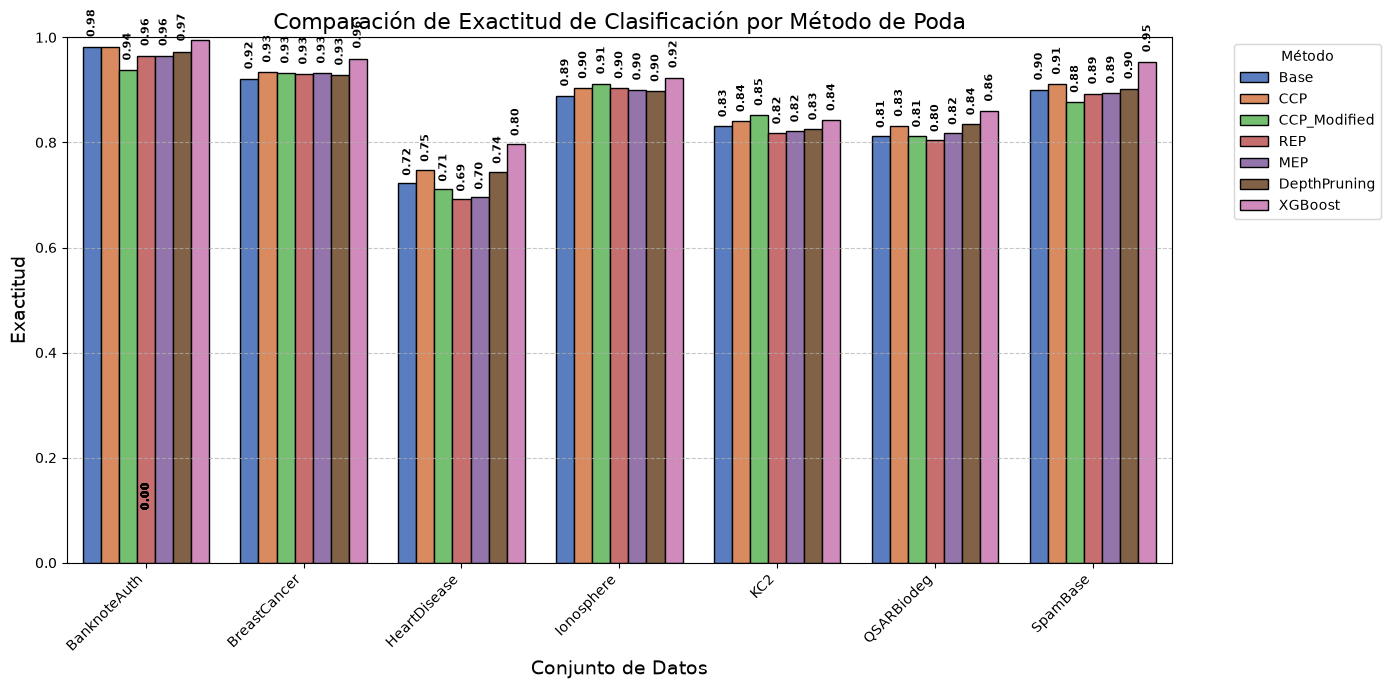

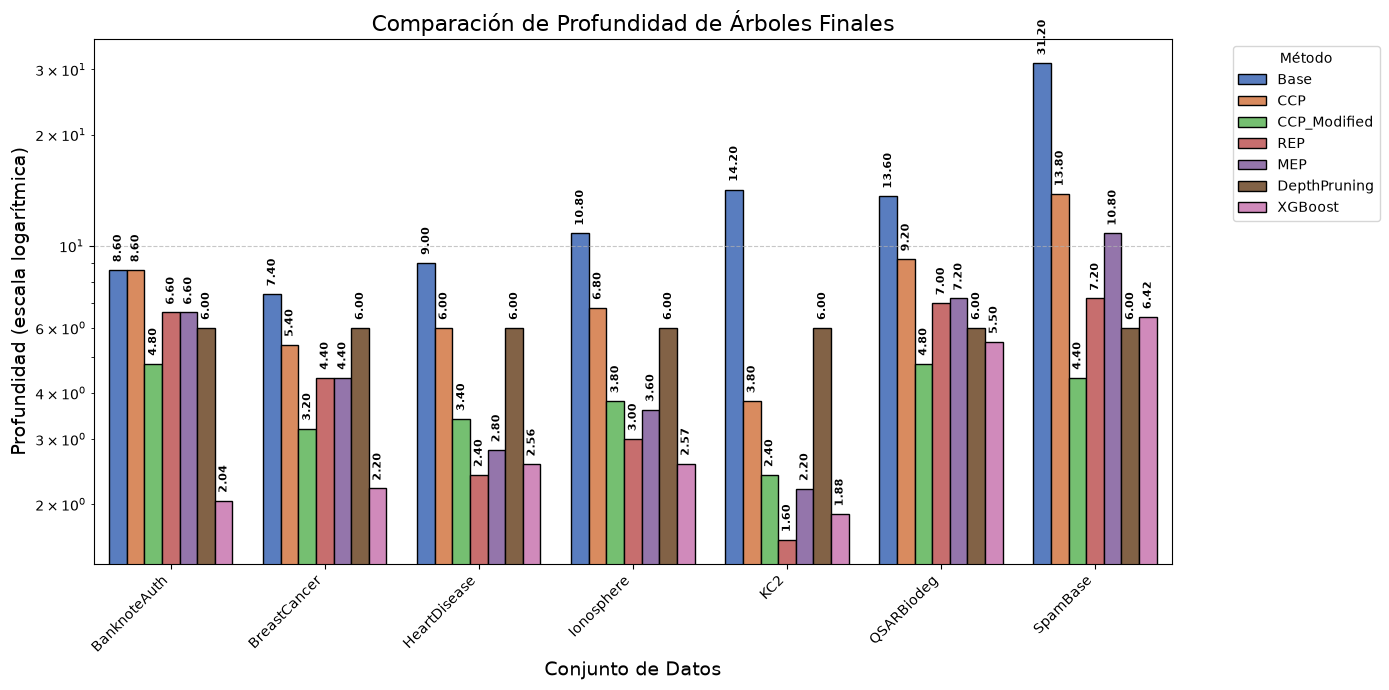

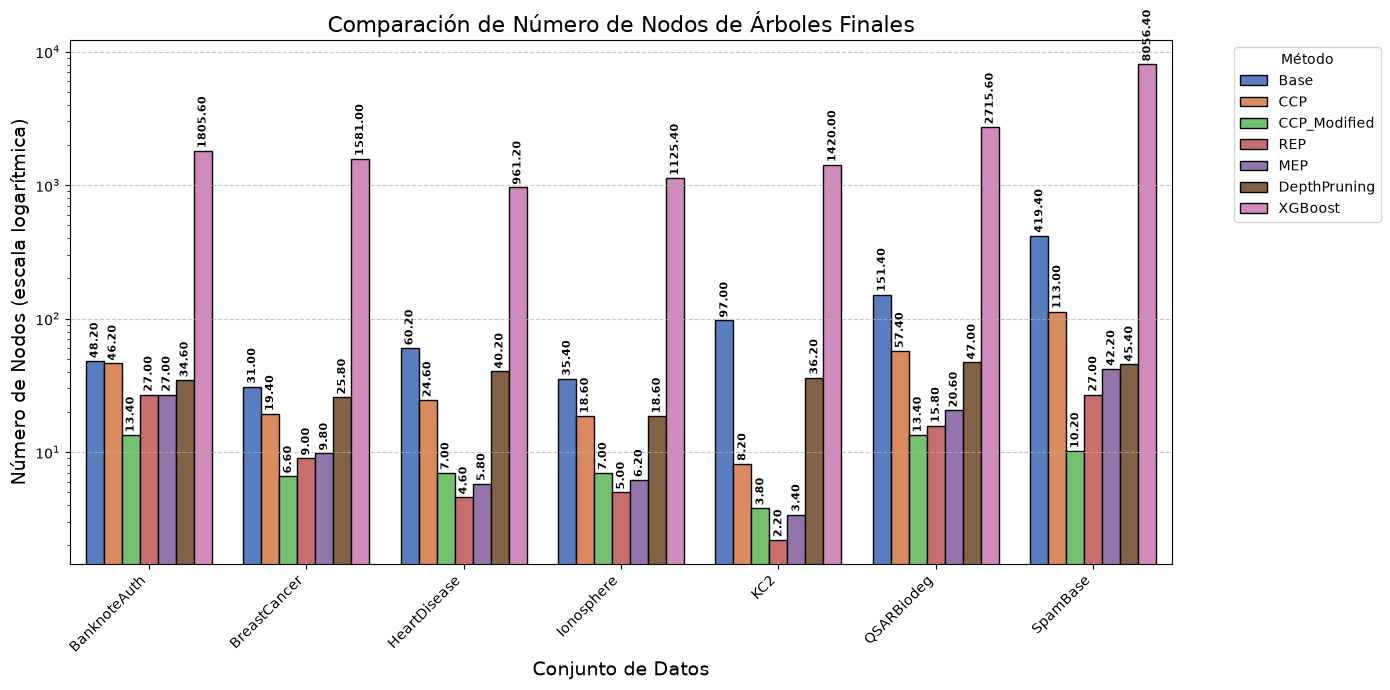

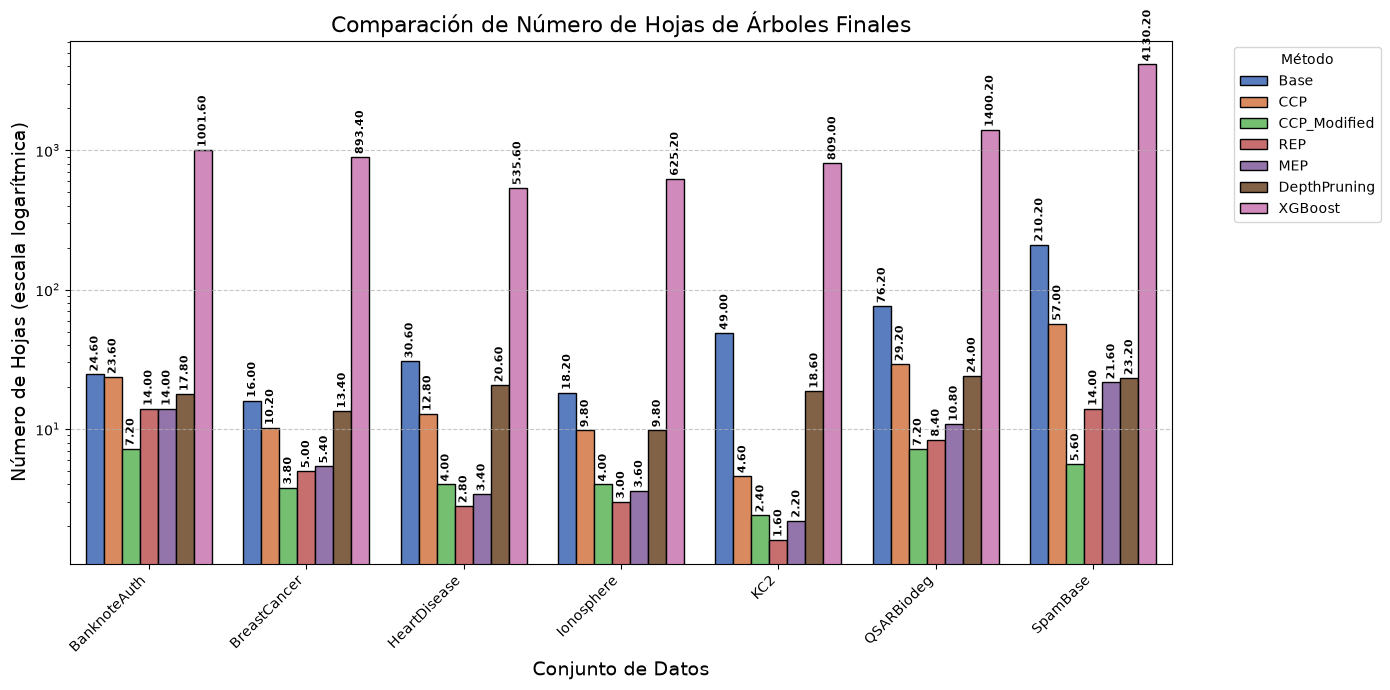

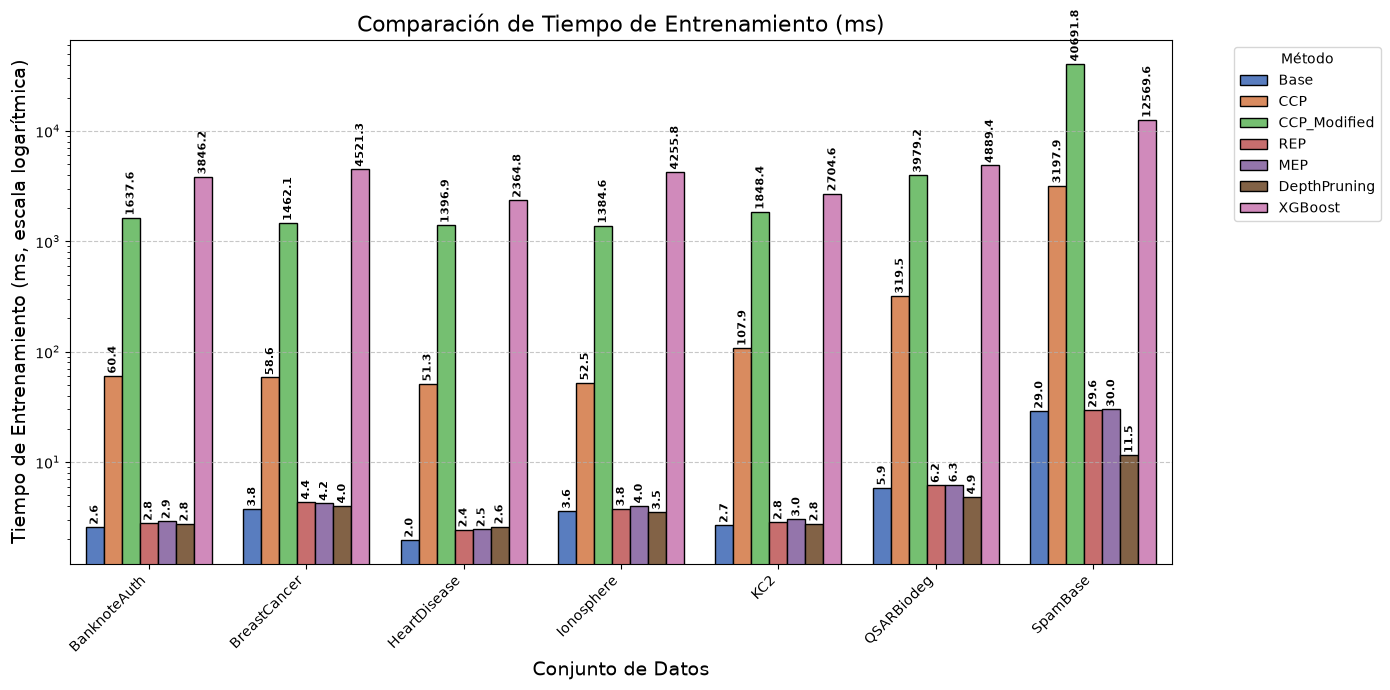

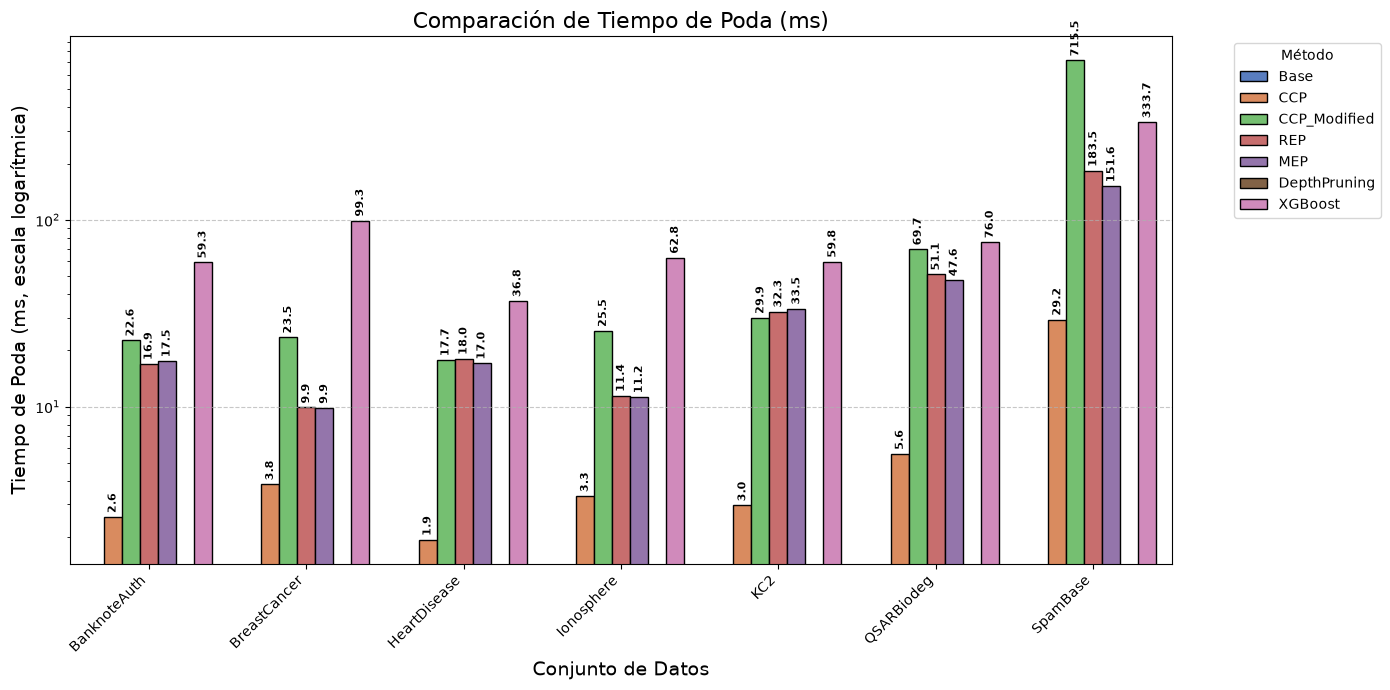

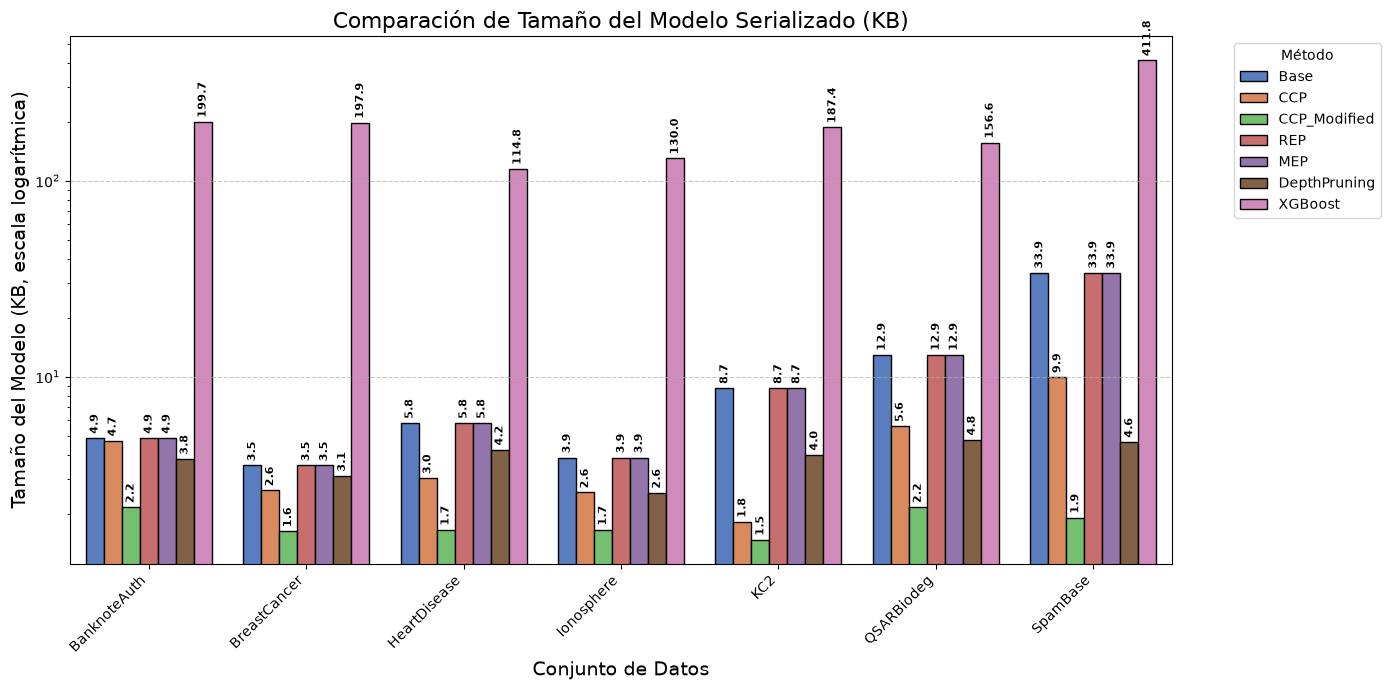

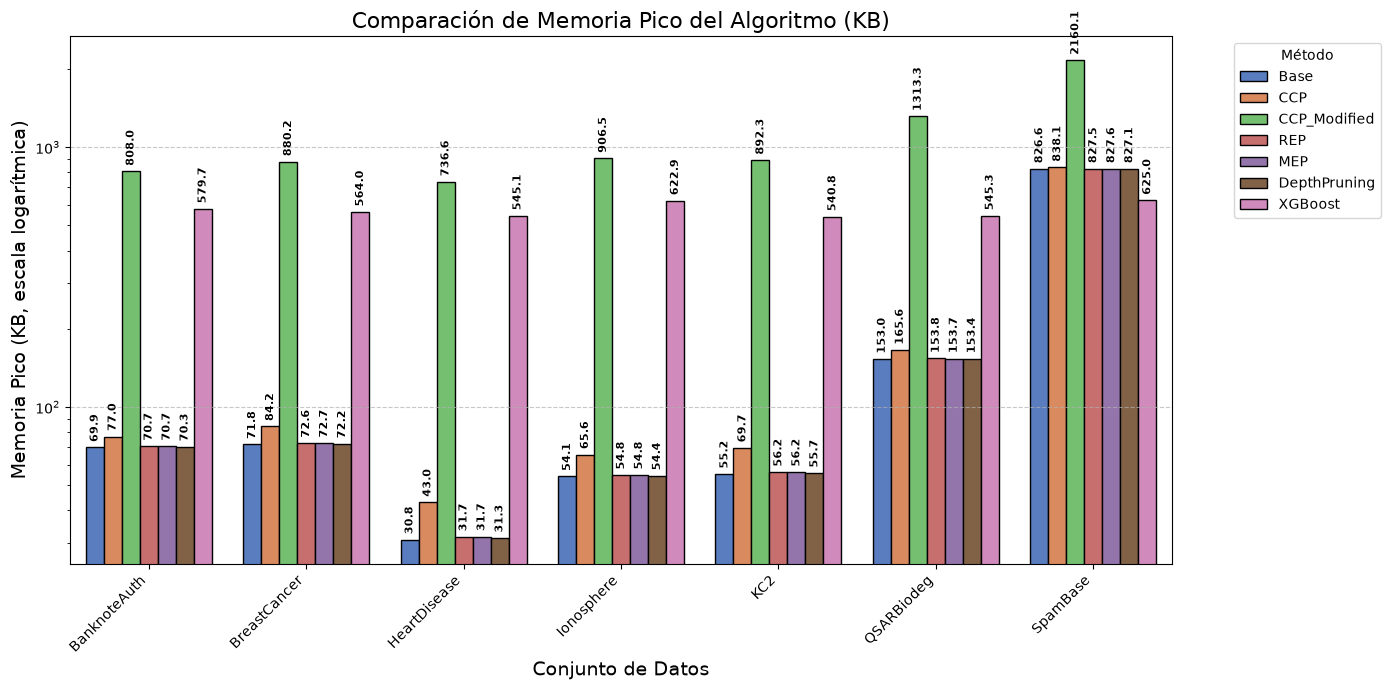

In [11]:
# ======================= RESULTADOS ===========================
results_df = pd.DataFrame(results, columns=[
    "Dataset", "Method", "Accuracy", "F1_Score", "Balanced_Accuracy",
    "Depth", "Nodes", "Leaves", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features",
    "Train_Time_ms", "Prune_Time_ms", "Memory_KB", "Peak_Memory_KB"
])
print(results_df)

# ========== RESULTADOS ADICIONALES ==========
metrics_df = results_df[["Dataset", "Method", "Accuracy", "F1_Score", "Balanced_Accuracy", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features", "Train_Time_ms", "Prune_Time_ms", "Memory_KB", "Peak_Memory_KB"]]
accuracy_df = results_df[["Dataset", "Method", "Accuracy"]].rename(columns={"Accuracy": "Test Accuracy"})
details_df = results_df[["Dataset", "Method", "Depth", "Nodes", "Leaves"]]

print("\nMetricas de Prueba por Método:")
print(metrics_df.pivot(index="Dataset", columns="Method"))

print("\nDetalles de Árboles:")
print(details_df)

#========================== ANOVA ===================================

anova_result_acc = f_oneway(*[group['Accuracy'].values for name, group in metrics_df.groupby('Method')])
anova_result_f1 = f_oneway(*[group['F1_Score'].values for name, group in metrics_df.groupby('Method')])
anova_result_bal = f_oneway(*[group['Balanced_Accuracy'].values for name, group in metrics_df.groupby('Method')])

anova_result_depth = f_oneway(*[group['Depth'].values for name, group in details_df.groupby('Method')])
anova_result_nodes = f_oneway(*[group['Nodes'].values for name, group in details_df.groupby('Method')])
anova_result_leav = f_oneway(*[group['Leaves'].values for name, group in details_df.groupby('Method')])

anova_featu_nodes = f_oneway(*[group['n_Features'].values for name, group in metrics_df.groupby('Method')])
print(f'ANOVA Accuracy:     F={anova_result_acc.statistic:.2f}, p={anova_result_acc.pvalue:.4f}')
print(f'ANOVA F1:           F={anova_result_f1.statistic:.2f}, p={anova_result_f1.pvalue:.4f}')
print(f'ANOVA Balanced Acc: F={anova_result_bal.statistic:.2f}, p={anova_result_bal.pvalue:.4f}')
print(f'ANOVA Depth:        F={anova_result_depth.statistic:.2f}, p={anova_result_depth.pvalue:.4f}')
print(f'ANOVA Nodes:        F={anova_result_nodes.statistic:.2f}, p={anova_result_nodes.pvalue:.4f}')
print(f'ANOVA Leaves:       F={anova_result_leav.statistic:.2f}, p={anova_result_leav.pvalue:.4f}')
print(f'ANOVA Features:     F={anova_featu_nodes.statistic:.2f}, p={anova_featu_nodes.pvalue:.4f}')

# ========================== CSV FINAL UNIFICADO CON Δacc ==========================

# Obtener accuracy base por dataset
base_accuracies = results_df[results_df["Method"] == "Base"][["Dataset", "Accuracy"]].set_index("Dataset")

# Añadir columna Δacc
results_df["△acc"] = results_df.apply(
    lambda row: row["Accuracy"] - base_accuracies.loc[row["Dataset"], "Accuracy"]
    if row["Method"] != "Base" else 0.0,
    axis=1
)

# Reordenar y renombrar columnas
final_df = results_df[["Dataset", "Method", "Accuracy", "△acc", "F1_Score", "Balanced_Accuracy", "Leaves", "Nodes", "Depth", "Inference_Time_ms", "Inference_Time_Std_ms", "n_Features", "Train_Time_ms", "Prune_Time_ms", "Memory_KB", "Peak_Memory_KB"]]

# Guardar CSV final
final_df.to_csv("FINAL_RESULTADOS.csv", index=False)

# Mostrar resumen final
print("\nCSV Final Consolidado:")
print(final_df)


# Descargar en Colab si aplica
try:
    from google.colab import files
    files.download("FINAL_RESULTADOS.csv")
except:
    print("Descarga automática no disponible (no estás en Colab).")


#==============GRAFICAS INTERPRETABLES==================


# Función para anotar las barras
def annotate_bars(ax, fmt="{:.2f}"):
    """Añade etiquetas numéricas encima de cada barra, separadas adecuadamente."""
    for p in ax.patches:
        height = p.get_height()
        offset = height * 0.020 if height > 0 else 0.1
        ax.annotate(fmt.format(height),
                    (p.get_x() + p.get_width() / 2., height + offset),
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color='black', rotation=90)

# === Gráfica 1: Exactitud por Método ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=accuracy_df, x="Dataset", y="Test Accuracy", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Exactitud de Clasificación por Método de Poda", fontsize=16)
plt.ylabel("Exactitud", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

#CARACTERÍSTICAS

# Función para anotar las barras correctamente, incluso las de valor 0
def annotate_bars(ax, fmt="{:.2f}"):
    """Añade etiquetas numéricas encima de cada barra, manejando valores cero correctamente."""
    for p in ax.patches:
        height = p.get_height()
        if height == 0:
            ax.annotate("0",
                        (p.get_x() + p.get_width() / 2., 0.2),
                        ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color='black', rotation=90)
        else:
            offset = height * 0.05
            ax.annotate(fmt.format(height),
                        (p.get_x() + p.get_width() / 2., height + offset),
                        ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color='black', rotation=90)

# === Gráfica 2: Profundidad de Árboles (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Depth", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Profundidad de Árboles Finales", fontsize=16)
plt.ylabel("Profundidad (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 3: Cantidad de Nodos (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Nodes", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Número de Nodos de Árboles Finales", fontsize=16)
plt.ylabel("Número de Nodos (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 4: Cantidad de Hojas (con escala logarítmica) ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=details_df, x="Dataset", y="Leaves", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Número de Hojas de Árboles Finales", fontsize=16)
plt.ylabel("Número de Hojas (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# === Gráfica 5: Tiempo de Entrenamiento (escala log) ===
train_time_df = results_df[["Dataset", "Method", "Train_Time_ms"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=train_time_df, x="Dataset", y="Train_Time_ms", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Tiempo de Entrenamiento (ms)", fontsize=16)
plt.ylabel("Tiempo de Entrenamiento (ms, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

# === Gráfica 6: Tiempo de Poda (escala log) ===
prune_time_df = results_df[["Dataset", "Method", "Prune_Time_ms"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=prune_time_df, x="Dataset", y="Prune_Time_ms", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Tiempo de Poda (ms)", fontsize=16)
plt.ylabel("Tiempo de Poda (ms, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

# === Gráfica 7: Memoria del Modelo Serializado (escala log) ===
memory_df = results_df[["Dataset", "Method", "Memory_KB"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=memory_df, x="Dataset", y="Memory_KB", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Tamaño del Modelo Serializado (KB)", fontsize=16)
plt.ylabel("Tamaño del Modelo (KB, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()

# === Gráfica 8: Memoria Pico del Algoritmo (escala log) ===
peak_memory_df = results_df[["Dataset", "Method", "Peak_Memory_KB"]]
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=peak_memory_df, x="Dataset", y="Peak_Memory_KB", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de Memoria Pico del Algoritmo (KB)", fontsize=16)
plt.ylabel("Memoria Pico (KB, escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.show()



SIGNIFICANCE ANALYSIS: Accuracy
Methods: ['Base', 'CCP', 'DBP', 'MEP', 'REP', 'SR-CCP']
Target method: SR-CCP
Ranking direction: higher is better
Friedman chi2 = 29.5661, p = 0.000018

Average ranks (lower = better):
  SR-CCP              : 1.571
  MEP                 : 2.214
  CCP                 : 2.357
  REP                 : 3.929
  DBP                 : 5.357
  Base                : 5.571

Nemenyi Critical Difference (CD) = 5.1200

Pairwise rank differences (pairs exceeding CD are significant):
Pair                                        Rank Diff  Significant
--------------------------------------------------------------------
Base vs CCP                                     3.214           no
Base vs DBP                                     0.214           no
Base vs MEP                                     3.357           no
Base vs REP                                     1.643           no
Base vs SR-CCP                                  4.000           no
CCP vs DBP             

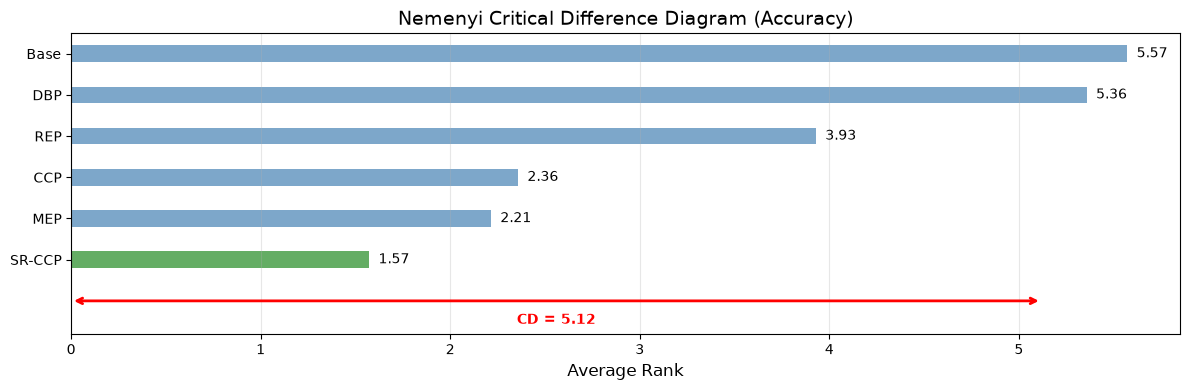


SIGNIFICANCE ANALYSIS: Leaves
Methods: ['Base', 'CCP', 'DBP', 'MEP', 'REP', 'SR-CCP']
Target method: SR-CCP
Ranking direction: lower is better
Friedman chi2 = 33.1148, p = 0.000004

Average ranks (lower = better):
  SR-CCP              : 1.000
  REP                 : 2.071
  MEP                 : 3.071
  DBP                 : 4.286
  CCP                 : 4.571
  Base                : 6.000

Nemenyi Critical Difference (CD) = 5.1200

Pairwise rank differences (pairs exceeding CD are significant):
Pair                                        Rank Diff  Significant
--------------------------------------------------------------------
Base vs CCP                                     1.429           no
Base vs DBP                                     1.714           no
Base vs MEP                                     2.929           no
Base vs REP                                     3.929           no
Base vs SR-CCP                                  5.000           no
CCP vs DBP                

In [12]:
# ====================== FRIEDMAN + NEMENYI TESTS ======================
from scipy.stats import friedmanchisquare, wilcoxon, ttest_rel, false_discovery_control
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ALPHA = 0.05
Q_VALUES = {
    (2, 2): 18.0, (2, 3): 6.16, (2, 4): 4.95, (2, 5): 4.60, (2, 6): 4.34, (2, 7): 4.16, (2, 8): 4.04,
    (2, 9): 3.95, (2, 10): 3.88, (2, 15): 3.65, (2, 20): 3.53, (2, 30): 3.40,
    (3, 3): 6.34, (3, 4): 5.24, (3, 5): 4.91, (3, 6): 4.68, (3, 7): 4.53, (3, 8): 4.41, (3, 9): 4.33, (3, 10): 4.26,
    (4, 4): 5.50, (4, 5): 5.16, (4, 6): 4.95, (4, 7): 4.79, (4, 8): 4.67, (4, 9): 4.59, (4, 10): 4.52,
    (5, 5): 5.33, (5, 6): 5.12, (5, 7): 4.99, (5, 8): 4.89, (5, 9): 4.81, (5, 10): 4.74,
    (6, 6): 5.24, (6, 7): 5.12, (6, 8): 5.02, (6, 9): 4.95, (6, 10): 4.88,
}


def resolve_target_method(methods, preferred_names):
    for name in preferred_names:
        if name in methods:
            return name
    raise ValueError(f'No se encontró un método objetivo entre: {preferred_names}')


def benchmark_significance(score_df, metric_name, higher_is_better=True, target_method=None, save_prefix=None, make_cd_plot=True):
    pivot = score_df.pivot(index='Dataset', columns='Method', values=metric_name)
    methods = list(pivot.columns)
    target_method = target_method or resolve_target_method(methods, ['SR-CCP', 'CCP_Modified'])

    if target_method not in methods:
        raise ValueError(f'El método objetivo {target_method} no existe en la métrica {metric_name}')

    ascending = not higher_is_better
    rank_matrix = pivot.rank(axis=1, ascending=ascending, method='average')
    avg_ranks = rank_matrix.mean(axis=0).sort_values()

    print('\n' + '=' * 80)
    print(f'SIGNIFICANCE ANALYSIS: {metric_name}')
    print('=' * 80)
    print(f'Methods: {methods}')
    print(f'Target method: {target_method}')
    print('Ranking direction: ' + ('higher is better' if higher_is_better else 'lower is better'))

    stat, pvalue = friedmanchisquare(*[pivot[m].values for m in methods])
    print(f'Friedman chi2 = {stat:.4f}, p = {pvalue:.6f}')

    print('\nAverage ranks (lower = better):')
    for method, rank in avg_ranks.items():
        print(f'  {method:20s}: {rank:.3f}')

    q_alpha = Q_VALUES.get((len(methods), len(pivot)), 4.039)
    cd = q_alpha * np.sqrt(len(methods) * (len(methods) + 1) / (6 * len(pivot)))
    print(f'\nNemenyi Critical Difference (CD) = {cd:.4f}')
    print('\nPairwise rank differences (pairs exceeding CD are significant):')
    print(f"{'Pair':<42s} {'Rank Diff':>10s} {'Significant':>12s}")
    print('-' * 68)
    for i, m1 in enumerate(methods):
        for m2 in methods[i + 1:]:
            diff = abs(avg_ranks[m1] - avg_ranks[m2])
            sig = 'YES ***' if diff >= cd else 'no'
            print(f'{m1 + " vs " + m2:<42s} {diff:>10.3f} {sig:>12s}')

    target_values = pivot[target_method].values
    other_methods = [m for m in methods if m != target_method]

    wilcoxon_rows = []
    for method in other_methods:
        other_values = pivot[method].values
        diff = target_values - other_values
        if np.all(diff == 0):
            stat_value, p_val = np.nan, np.nan
        else:
            stat_value, p_val = wilcoxon(target_values, other_values)
        wilcoxon_rows.append({'Method': method, 'Statistic': stat_value, 'p_value': p_val})

    wilcoxon_rows.sort(key=lambda row: row['p_value'] if not np.isnan(row['p_value']) else 1.0)
    wilcoxon_results = []

    wpvals = np.array([row['p_value'] for row in wilcoxon_rows])
    wvalid = ~np.isnan(wpvals)
    wbh = np.full_like(wpvals, np.nan)
    if wvalid.sum() > 0:
        wbh[wvalid] = false_discovery_control(wpvals[wvalid], method='bh')

    print('\nWilcoxon signed-rank test (two-sided, Benjamini-Hochberg / FDR correction):')
    print(f'BH correction for {len(other_methods)} comparisons')
    print(f"{'Method':<20s} {'W-stat':>8s} {'p-value':>10s} {'BH p':>10s} {'Significant':>12s}")
    print('-' * 65)
    for row, bh_p in zip(wilcoxon_rows, wbh):
        method = row['Method']
        stat_value = row['Statistic']
        p_val = row['p_value']
        if np.isnan(p_val):
            sig = 'N/A (all equal)'
        else:
            sig = 'YES ***' if bh_p < ALPHA else 'no'
        wilcoxon_results.append({
            'Metric': metric_name,
            'Method': method,
            'Test': 'Wilcoxon',
            'Statistic': stat_value,
            'p_value': p_val,
            'BH_p': bh_p,
            'Significant': sig,
        })
        stat_str = f'{stat_value:.2f}' if not np.isnan(stat_value) else 'N/A'
        p_str = f'{p_val:.6f}' if not np.isnan(p_val) else 'N/A'
        bh_str = f'{bh_p:.6f}' if not np.isnan(bh_p) else 'N/A'
        print(f'{method:<20s} {stat_str:>8s} {p_str:>10s} {bh_str:>10s} {sig:>12s}')

    ttest_rows = []
    for method in other_methods:
        other_values = pivot[method].values
        stat_value, p_val = ttest_rel(target_values, other_values)
        ttest_rows.append({'Method': method, 'Statistic': stat_value, 'p_value': p_val})

    ttest_rows.sort(key=lambda row: row['p_value'])
    ttest_results = []

    tpvals = np.array([row['p_value'] for row in ttest_rows])
    tbh = false_discovery_control(tpvals, method='bh')

    print('\nPaired t-test (two-sided, Benjamini-Hochberg / FDR correction):')
    print(f'BH correction for {len(other_methods)} comparisons')
    print(f"{'Method':<20s} {'t-stat':>8s} {'p-value':>10s} {'BH p':>10s} {'Significant':>12s}")
    print('-' * 65)
    for row, bh_p in zip(ttest_rows, tbh):
        method = row['Method']
        stat_value = row['Statistic']
        p_val = row['p_value']
        sig = 'YES ***' if bh_p < ALPHA else 'no'
        ttest_results.append({
            'Metric': metric_name,
            'Method': method,
            'Test': 'Paired t-test',
            'Statistic': stat_value,
            'p_value': p_val,
            'BH_p': bh_p,
            'Significant': sig,
        })
        print(f'{method:<20s} {stat_value:>8.2f} {p_val:>10.6f} {bh_p:>10.6f} {sig:>12s}')

    if make_cd_plot:
        fig, ax = plt.subplots(figsize=(12, 4))
        sorted_ranks = avg_ranks.sort_values()
        for i, (method, rank) in enumerate(sorted_ranks.items()):
            color = 'forestgreen' if method == target_method else 'steelblue'
            ax.barh(i, rank, height=0.4, color=color, alpha=0.7)
            ax.text(rank + 0.05, i, f'{rank:.2f}', va='center', fontsize=10)

        y_cd = -1
        ax.annotate('', xy=(0, y_cd), xytext=(cd, y_cd),
                    arrowprops=dict(arrowstyle='<->', color='red', lw=2))
        ax.text(cd / 2, y_cd - 0.3, f'CD = {cd:.2f}', ha='center', va='top', color='red', fontweight='bold')

        ax.set_yticks(range(len(sorted_ranks)))
        ax.set_yticklabels(sorted_ranks.index, fontsize=10)
        ax.set_xlabel('Average Rank', fontsize=12)
        ax.set_title(f'Nemenyi Critical Difference Diagram ({metric_name})', fontsize=14)
        ax.set_ylim(-1.8, len(sorted_ranks) - 0.5)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        if save_prefix:
            plt.savefig(f'{save_prefix}_{metric_name}_nemenyi_cd_diagram.png', dpi=150, bbox_inches='tight')
        plt.show()

    summary_df = pd.DataFrame(wilcoxon_results + ttest_results)
    summary_df['Target_Method'] = target_method
    summary_df['Friedman_p'] = pvalue
    summary_df['CD'] = cd
    return summary_df


# --- 1. Accuracy significance on the paper results ---
acc_df = pd.read_csv('paper/RESULTADOS_PAPER.csv')
acc_summary = benchmark_significance(
    acc_df,
    metric_name='Accuracy',
    higher_is_better=True,
    target_method='SR-CCP',
    save_prefix='paper',
    make_cd_plot=True,
)
acc_summary.to_csv('paper/accuracy_significance_summary.csv', index=False)

# --- 2. Structural significance on the final consolidated results ---
struct_df = pd.read_csv('paper/RESULTADOS_PAPER.csv')
struct_metrics = ['Leaves', 'Nodes', 'Depth', 'Features']
struct_summaries = []

for metric_name in struct_metrics:
    summary_df = benchmark_significance(
        struct_df,
        metric_name=metric_name,
        higher_is_better=False,
        target_method='SR-CCP',
        save_prefix='final',
        make_cd_plot=False,
    )
    struct_summaries.append(summary_df)

struct_summary = pd.concat(struct_summaries, ignore_index=True)
struct_summary.to_csv('FINAL_RESULTADOS_structural_significance.csv', index=False)
print('\nStructural significance summary saved to FINAL_RESULTADOS_structural_significance.csv')


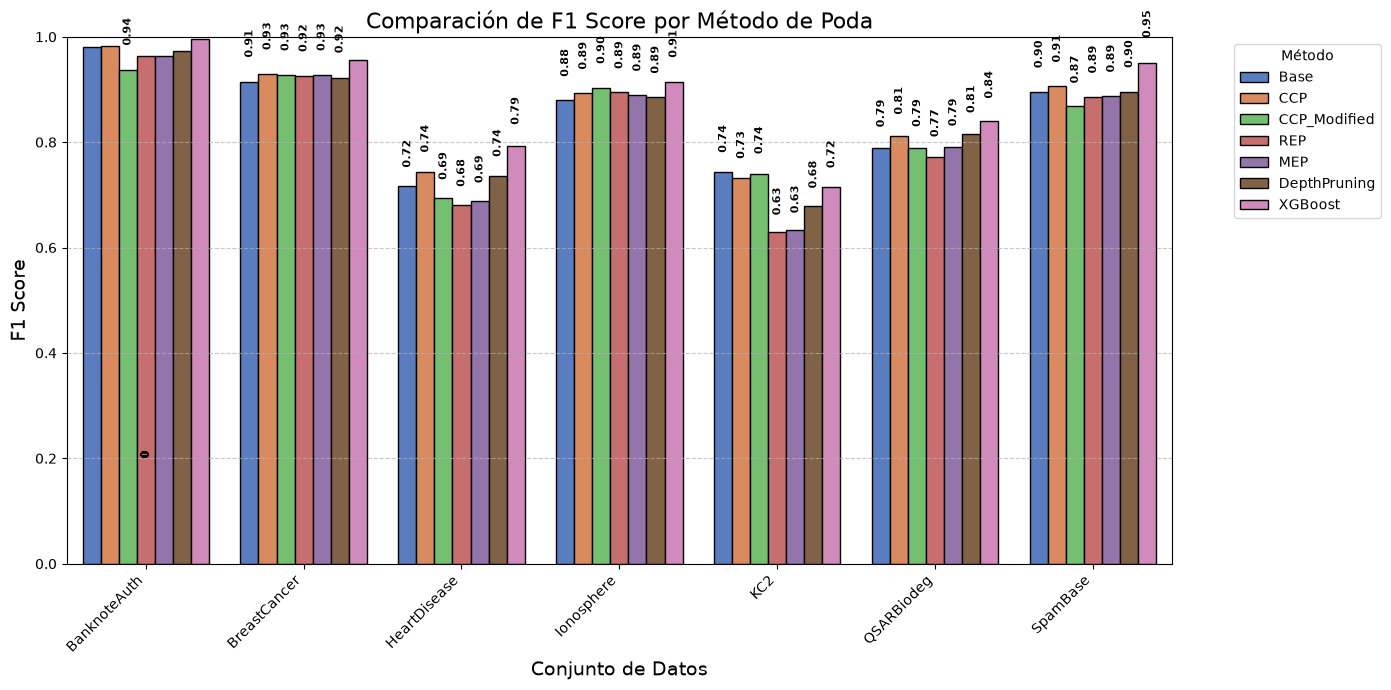

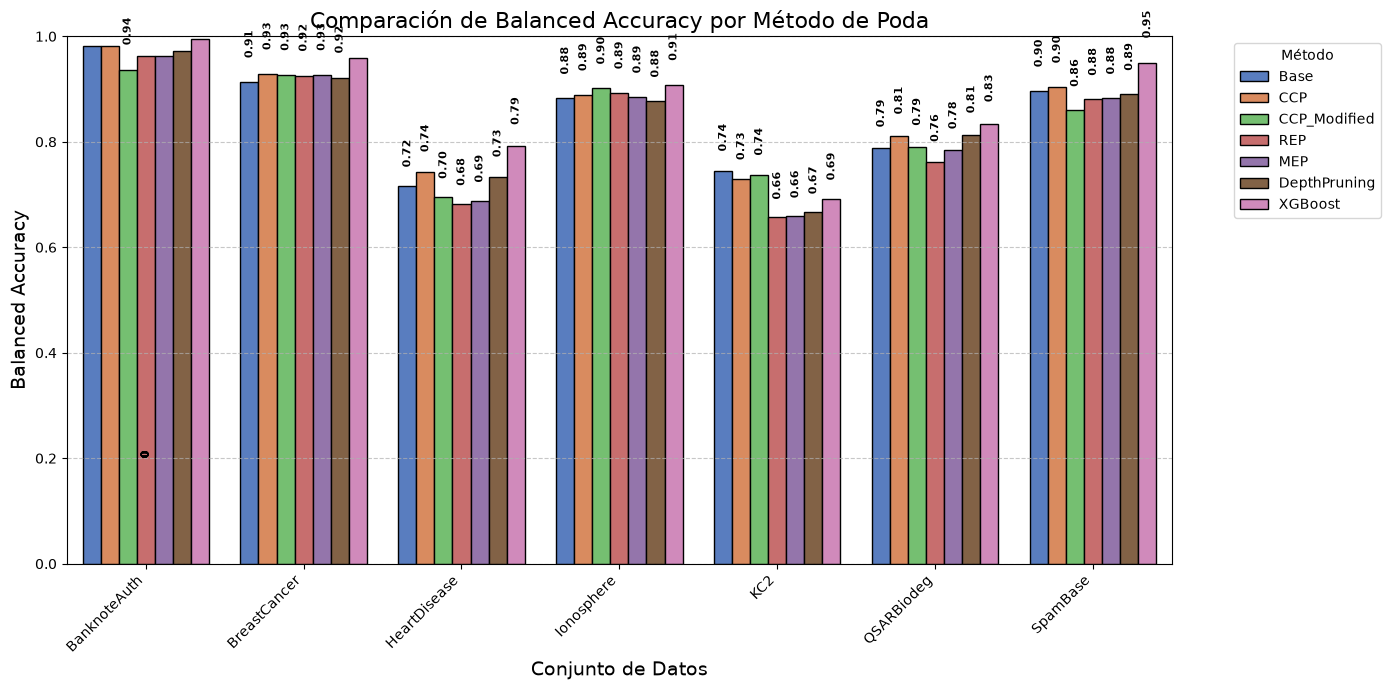

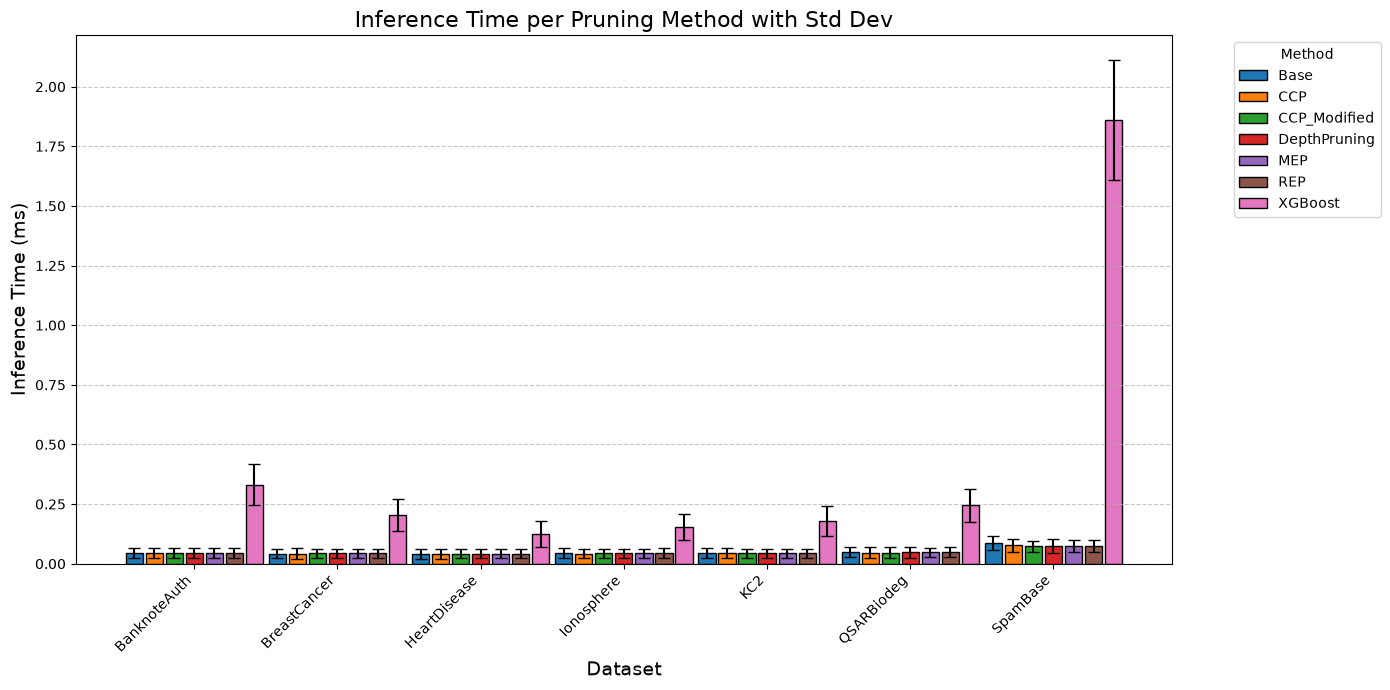

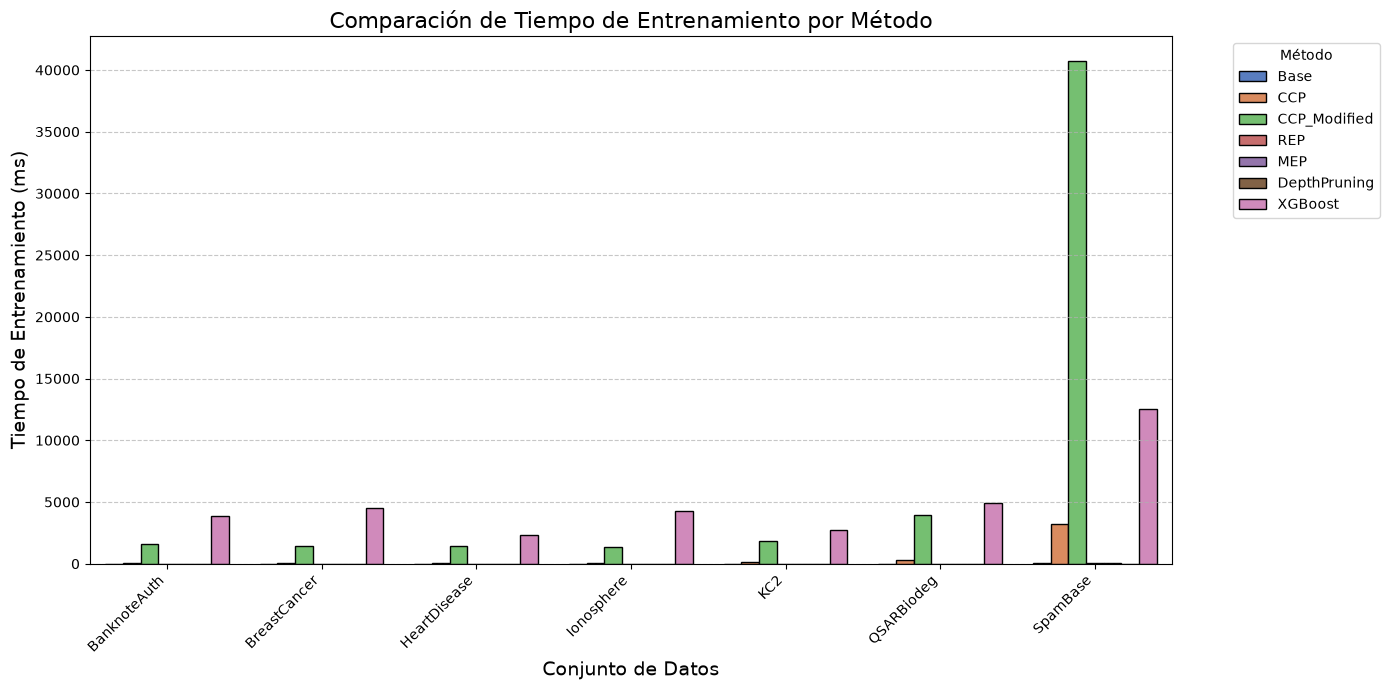

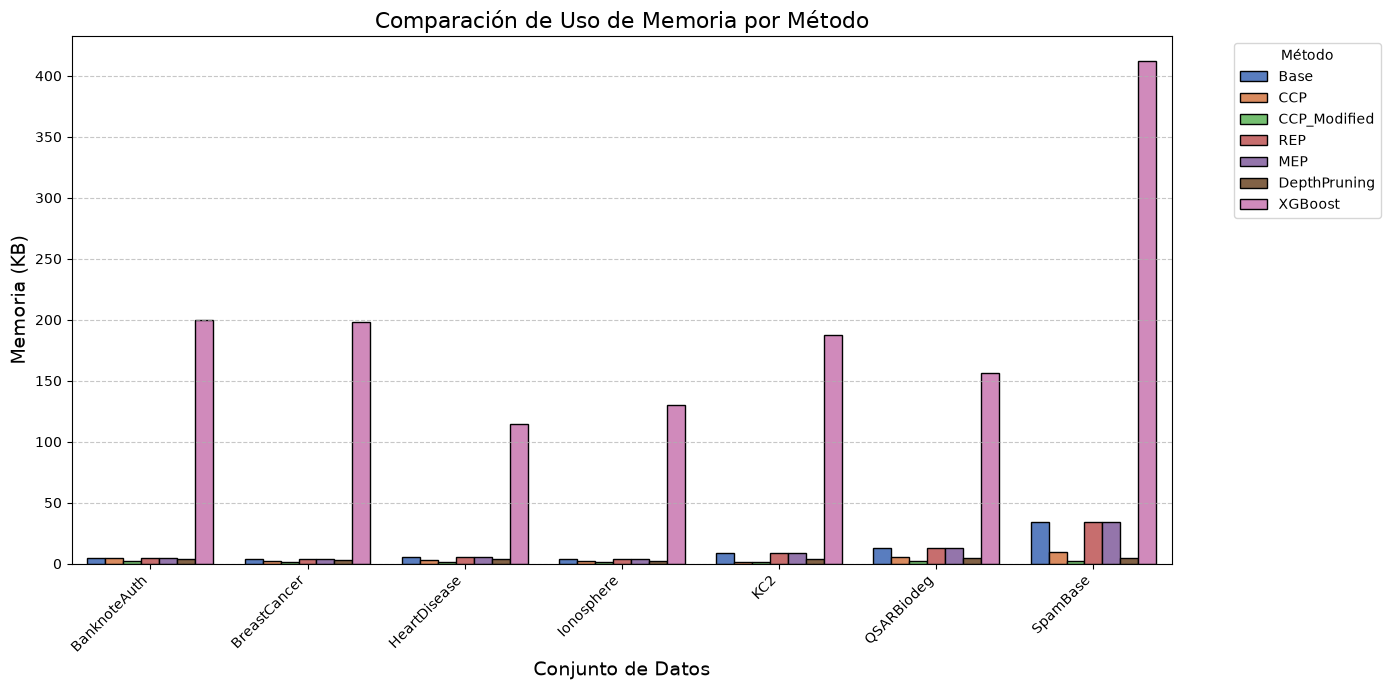

In [13]:
# Gráfica de barras para F1 Score
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="F1_Score", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de F1 Score por Método de Poda", fontsize=16)
plt.ylabel("F1 Score", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()

# Gráfica de barras para Balanced Accuracy
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Balanced_Accuracy", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Balanced Accuracy por Método de Poda", fontsize=16)
plt.ylabel("Balanced Accuracy", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()




# Compute average and std per group
grouped = metrics_df.groupby(["Dataset", "Method"], as_index=False).mean()

# Create the bar plot with error bars
plt.figure(figsize=(14, 7))

# Get unique methods and datasets
methods = grouped["Method"].unique()
datasets = grouped["Dataset"].unique()

# Create position indices for grouped bars
x = np.arange(len(datasets))
width = 0.12  # width of each bar
offsets = np.linspace(-width*len(methods)/2, width*len(methods)/2, len(methods))

for i, method in enumerate(methods):
    subset = grouped[grouped["Method"] == method]
    y = subset["Inference_Time_ms"].values
    yerr = subset["Inference_Time_Std_ms"].values
    plt.bar(x + offsets[i], y, width, label=method, yerr=yerr, capsize=4, edgecolor="black")

plt.xticks(x, datasets, rotation=45, ha="right")
plt.title("Inference Time per Pruning Method with Std Dev", fontsize=16)
plt.xlabel("Dataset", fontsize=14)
plt.ylabel("Inference Time (ms)", fontsize=14)
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.ylim(bottom=0)
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# === Gráfica: Tiempo de Entrenamiento ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Train_Time_ms", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Tiempo de Entrenamiento por Método", fontsize=16)
plt.ylabel("Tiempo de Entrenamiento (ms)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# === Gráfica: Uso de Memoria ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="Memory_KB", hue="Method", palette="muted", edgecolor="black")
plt.title("Comparación de Uso de Memoria por Método", fontsize=16)
plt.ylabel("Memoria (KB)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


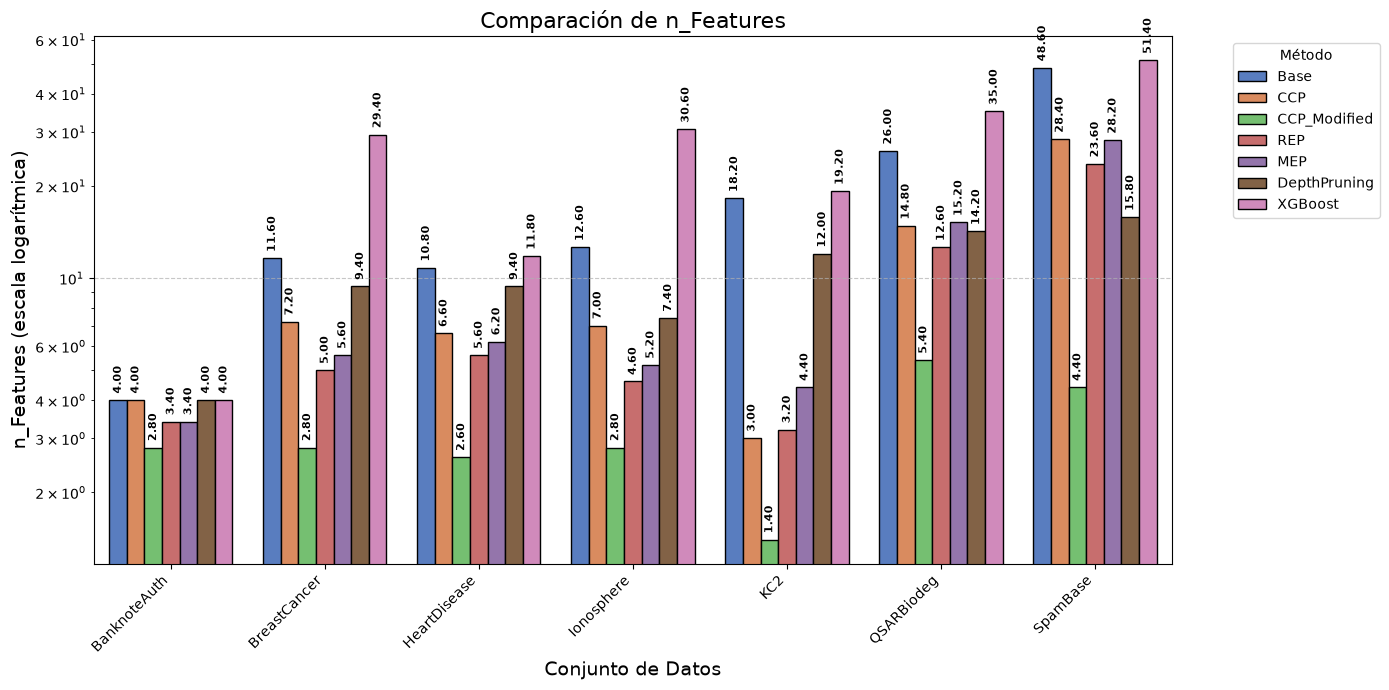

In [14]:
# === Gráfica 5: n_Features ===
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=metrics_df, x="Dataset", y="n_Features", hue="Method", palette="muted", edgecolor="black")
plt.yscale('log')
plt.title("Comparación de n_Features", fontsize=16)
plt.ylabel("n_Features (escala logarítmica)", fontsize=14)
plt.xlabel("Conjunto de Datos", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle='--', alpha=0.7)
plt.legend(title="Método", bbox_to_anchor=(1.05, 1), loc='upper left')
annotate_bars(ax, fmt="{:.2f}")
plt.tight_layout()
plt.show()


Sensitivity analysis for BanknoteAuth


[I 2026-07-05 18:48:05,869] A new study created in memory with name: no-name-116176b4-2ed4-4132-aa2e-c9d1bb63db27
[I 2026-07-05 18:48:05,904] Trial 0 finished with value: 0.8252427184466019 and parameters: {'depth_penalty': 0.003807947176588889, 'feature_penalty_weight': 0.19063571821788408}. Best is trial 0 with value: 0.8252427184466019.
[I 2026-07-05 18:48:05,935] Trial 1 finished with value: 0.8252427184466019 and parameters: {'depth_penalty': 0.007346740023932911, 'feature_penalty_weight': 0.12374511199743694}. Best is trial 0 with value: 0.8252427184466019.
[I 2026-07-05 18:48:05,968] Trial 2 finished with value: 0.8737864077669902 and parameters: {'depth_penalty': 0.0016445845403801217, 'feature_penalty_weight': 0.039638958863878505}. Best is trial 2 with value: 0.8737864077669902.
[I 2026-07-05 18:48:06,000] Trial 3 finished with value: 0.8252427184466019 and parameters: {'depth_penalty': 0.0006750277604651748, 'feature_penalty_weight': 0.1745734676972377}. Best is trial 2 with

Best reference params: depth_penalty=0.001645, feature_penalty_weight=0.039639
Best reference validation accuracy: 0.8738


[I 2026-07-05 18:48:07,091] A new study created in memory with name: no-name-28464b43-d783-4bf8-975f-7c41b356689b
[I 2026-07-05 18:48:07,135] Trial 0 finished with value: 0.9181286549707602 and parameters: {'depth_penalty': 0.003807947176588889, 'feature_penalty_weight': 0.19063571821788408}. Best is trial 0 with value: 0.9181286549707602.
[I 2026-07-05 18:48:07,172] Trial 1 finished with value: 0.9181286549707602 and parameters: {'depth_penalty': 0.007346740023932911, 'feature_penalty_weight': 0.12374511199743694}. Best is trial 0 with value: 0.9181286549707602.
[I 2026-07-05 18:48:07,211] Trial 2 finished with value: 0.9181286549707602 and parameters: {'depth_penalty': 0.0016445845403801217, 'feature_penalty_weight': 0.039638958863878505}. Best is trial 0 with value: 0.9181286549707602.
[I 2026-07-05 18:48:07,251] Trial 3 finished with value: 0.9181286549707602 and parameters: {'depth_penalty': 0.0006750277604651748, 'feature_penalty_weight': 0.1745734676972377}. Best is trial 0 with


Sensitivity analysis for BreastCancer


...


Sensitivity analysis for QSARBiodeg


[I 2026-07-05 18:48:12,482] Trial 0 finished with value: 0.7570977917981072 and parameters: {'depth_penalty': 0.003807947176588889, 'feature_penalty_weight': 0.19063571821788408}. Best is trial 0 with value: 0.7570977917981072.
[I 2026-07-05 18:48:12,813] Trial 1 finished with value: 0.7570977917981072 and parameters: {'depth_penalty': 0.007346740023932911, 'feature_penalty_weight': 0.12374511199743694}. Best is trial 0 with value: 0.7570977917981072.
[I 2026-07-05 18:48:13,143] Trial 2 finished with value: 0.7602523659305994 and parameters: {'depth_penalty': 0.0016445845403801217, 'feature_penalty_weight': 0.039638958863878505}. Best is trial 2 with value: 0.7602523659305994.
[I 2026-07-05 18:48:13,475] Trial 3 finished with value: 0.7570977917981072 and parameters: {'depth_penalty': 0.0006750277604651748, 'feature_penalty_weight': 0.1745734676972377}. Best is trial 2 with value: 0.7602523659305994.
[I 2026-07-05 18:48:13,815] Trial 4 finished with value: 0.7570977917981072 and parame

Best reference params: depth_penalty=0.001645, feature_penalty_weight=0.039639
Best reference validation accuracy: 0.7603

Sensitivity analysis for SpamBase


[I 2026-07-05 18:48:24,288] A new study created in memory with name: no-name-27130520-edc9-452f-9f66-1896039dd04f
[I 2026-07-05 18:48:27,320] Trial 0 finished with value: 0.8689355539464156 and parameters: {'depth_penalty': 0.003807947176588889, 'feature_penalty_weight': 0.19063571821788408}. Best is trial 0 with value: 0.8689355539464156.
[I 2026-07-05 18:48:30,354] Trial 1 finished with value: 0.8479362780593772 and parameters: {'depth_penalty': 0.007346740023932911, 'feature_penalty_weight': 0.12374511199743694}. Best is trial 0 with value: 0.8689355539464156.
[I 2026-07-05 18:48:33,398] Trial 2 finished with value: 0.8819695872556119 and parameters: {'depth_penalty': 0.0016445845403801217, 'feature_penalty_weight': 0.039638958863878505}. Best is trial 2 with value: 0.8819695872556119.
[I 2026-07-05 18:48:36,418] Trial 3 finished with value: 0.8689355539464156 and parameters: {'depth_penalty': 0.0006750277604651748, 'feature_penalty_weight': 0.1745734676972377}. Best is trial 2 with

Best reference params: depth_penalty=0.001645, feature_penalty_weight=0.039639
Best reference validation accuracy: 0.8820

Mean sensitivity summary (depth_penalty sweep):
  depth_penalty accuracy         balanced_accuracy           depth          \
                    mean     std              mean     std    mean     std   
0        0.0001   0.8524  0.0674            0.8221  0.0953  2.4286  0.9759   
1        0.0002   0.8524  0.0674            0.8221  0.0953  2.4286  0.9759   
2        0.0004   0.8469  0.0631            0.8159  0.0896  2.2857  0.9512   
3        0.0007   0.8453  0.0619            0.8148  0.0887  2.1429  0.6901   
4        0.0014   0.8435  0.0645            0.8105  0.0940  2.1429  0.6901   
5        0.0027   0.8417  0.0634            0.8090  0.0929  2.1429  0.6901   
6        0.0052   0.8412  0.0641            0.8152  0.0858  1.8571  0.6901   
7        0.0100   0.8382  0.0630            0.8098  0.0836  1.7143  0.4880   

    nodes          leaves         n_features    

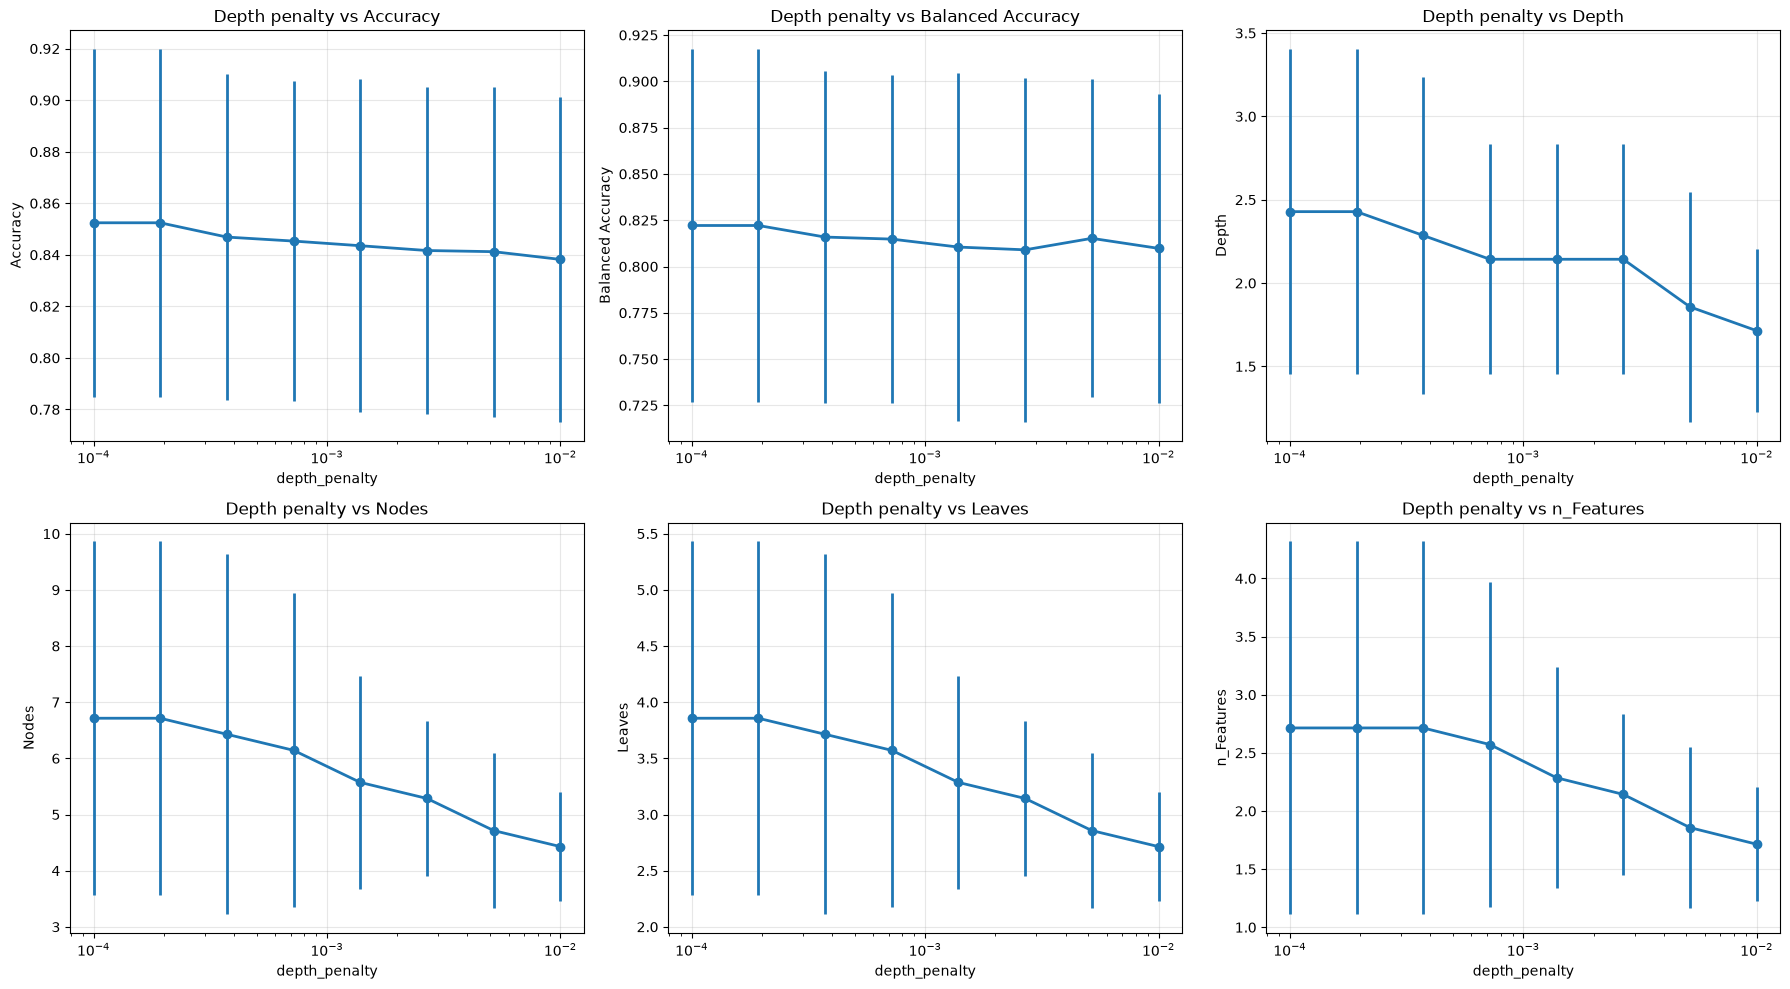

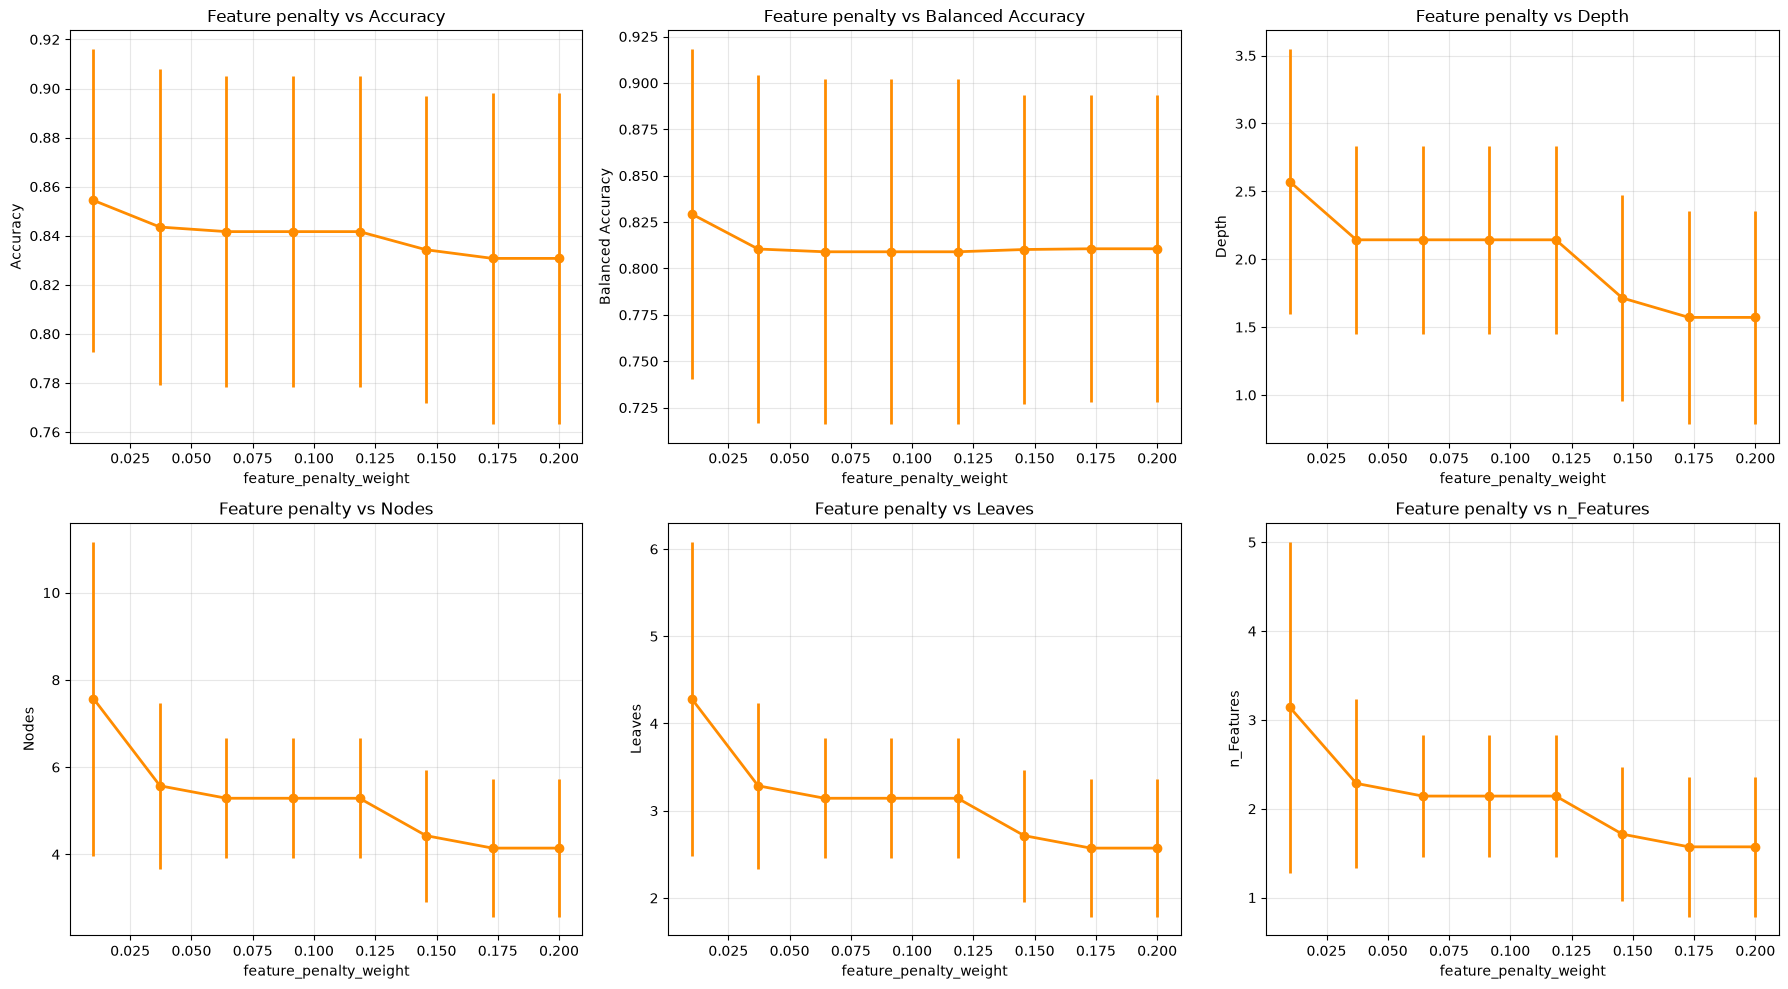

In [15]:
# ======================= SENSITIVITY ANALYSIS: OBS 21 =======================
from pathlib import Path
from sklearn.model_selection import train_test_split

SENS_DIR = Path('sensitivity_analysis')
SENS_DIR.mkdir(exist_ok=True)

DEPTH_GRID = np.geomspace(1e-4, 1e-2, 8)
FEATURE_GRID = np.linspace(0.01, 0.2, 8)
SENSITIVITY_TRIALS = 20
SENSITIVITY_SEED = 42


def build_ccp_candidates(X_train, y_train, X_val, y_val, seed=42):
    path = DecisionTreeClassifier(random_state=seed).cost_complexity_pruning_path(X_train, y_train)
    alphas = np.unique(path.ccp_alphas)

    def evaluate_alpha(alpha):
        model = DecisionTreeClassifier(random_state=seed, ccp_alpha=alpha)
        model.fit(X_train, y_train)
        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)
        return {
            'alpha': float(alpha),
            'acc_train': accuracy_score(y_train, train_pred),
            'acc_val': accuracy_score(y_val, val_pred),
            'depth': model.get_depth(),
            'nodes': model.tree_.node_count,
            'leaves': model.get_n_leaves(),
            'n_features': count_used_features(model),
        }

    return Parallel(n_jobs=-1)(delayed(evaluate_alpha)(alpha) for alpha in alphas)


def modified_alpha(candidate, depth_penalty, feature_penalty_weight, n_total_features):
    return (
        candidate['alpha'] * (1 + abs(candidate['acc_train'] - candidate['acc_val']))
        + depth_penalty * candidate['depth']
        + feature_penalty_weight * (candidate['n_features'] / n_total_features)
    )


def evaluate_param_pair(X_train, y_train, X_val, y_val, candidates, depth_penalty, feature_penalty_weight, seed=42):
    n_total_features = X_train.shape[1]
    best_score = -np.inf
    best_model = None
    best_alpha = None

    for candidate in candidates:
        alpha = modified_alpha(candidate, depth_penalty, feature_penalty_weight, n_total_features)
        model = DecisionTreeClassifier(random_state=seed, ccp_alpha=alpha)
        model.fit(X_train, y_train)
        score = accuracy_score(y_val, model.predict(X_val))
        if score > best_score:
            best_score = score
            best_model = model
            best_alpha = alpha

    predictions = best_model.predict(X_val)
    return {
        'accuracy': accuracy_score(y_val, predictions),
        'f1': f1_score(y_val, predictions, average='weighted'),
        'balanced_accuracy': balanced_accuracy_score(y_val, predictions),
        'depth': best_model.get_depth(),
        'nodes': best_model.tree_.node_count,
        'leaves': best_model.get_n_leaves(),
        'n_features': count_used_features(best_model),
        'best_alpha': best_alpha,
        'best_score': best_score,
    }


def tune_reference_params(candidates, X_train, y_train, X_val, y_val, seed=42, n_trials=20):
    n_total_features = X_train.shape[1]

    def objective(trial):
        depth_penalty = trial.suggest_float('depth_penalty', 0.0001, 0.01)
        feature_penalty_weight = trial.suggest_float('feature_penalty_weight', 0.01, 0.2)
        best_val = -np.inf
        for candidate in candidates:
            alpha = modified_alpha(candidate, depth_penalty, feature_penalty_weight, n_total_features)
            model = DecisionTreeClassifier(random_state=seed, ccp_alpha=alpha)
            model.fit(X_train, y_train)
            score = accuracy_score(y_val, model.predict(X_val))
            if score > best_val:
                best_val = score
        return best_val

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params, study.best_value


sensitivity_rows = []
summary_rows = []
datasets = load_datasets()

for ds_name, X, y in datasets:
    print(f"\n{'='*80}")
    print(f"Sensitivity analysis for {ds_name}")
    print(f"{'='*80}")
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.30, random_state=SENSITIVITY_SEED, stratify=y
    )

    candidates = build_ccp_candidates(X_train, y_train, X_val, y_val, seed=SENSITIVITY_SEED)
    best_params, best_reference = tune_reference_params(
        candidates, X_train, y_train, X_val, y_val, seed=SENSITIVITY_SEED, n_trials=SENSITIVITY_TRIALS
    )

    print(f"Best reference params: depth_penalty={best_params['depth_penalty']:.6f}, feature_penalty_weight={best_params['feature_penalty_weight']:.6f}")
    print(f"Best reference validation accuracy: {best_reference:.4f}")

    for depth_penalty in DEPTH_GRID:
        metrics = evaluate_param_pair(
            X_train, y_train, X_val, y_val, candidates,
            depth_penalty=float(depth_penalty),
            feature_penalty_weight=float(best_params['feature_penalty_weight']),
            seed=SENSITIVITY_SEED,
        )
        sensitivity_rows.append({
            'Dataset': ds_name,
            'Sweep': 'depth_penalty',
            'depth_penalty': float(depth_penalty),
            'feature_penalty_weight': float(best_params['feature_penalty_weight']),
            **metrics,
        })

    for feature_penalty_weight in FEATURE_GRID:
        metrics = evaluate_param_pair(
            X_train, y_train, X_val, y_val, candidates,
            depth_penalty=float(best_params['depth_penalty']),
            feature_penalty_weight=float(feature_penalty_weight),
            seed=SENSITIVITY_SEED,
        )
        sensitivity_rows.append({
            'Dataset': ds_name,
            'Sweep': 'feature_penalty_weight',
            'depth_penalty': float(best_params['depth_penalty']),
            'feature_penalty_weight': float(feature_penalty_weight),
            **metrics,
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(SENS_DIR / 'obs21_sensitivity_results.csv', index=False)

summary_depth = sensitivity_df[sensitivity_df['Sweep'] == 'depth_penalty'].groupby('depth_penalty').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'depth': ['mean', 'std'],
    'nodes': ['mean', 'std'],
    'leaves': ['mean', 'std'],
    'n_features': ['mean', 'std'],
}).reset_index()
summary_feature = sensitivity_df[sensitivity_df['Sweep'] == 'feature_penalty_weight'].groupby('feature_penalty_weight').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'depth': ['mean', 'std'],
    'nodes': ['mean', 'std'],
    'leaves': ['mean', 'std'],
    'n_features': ['mean', 'std'],
}).reset_index()

summary_depth.to_csv(SENS_DIR / 'obs21_depth_sensitivity_summary.csv', index=False)
summary_feature.to_csv(SENS_DIR / 'obs21_feature_sensitivity_summary.csv', index=False)

print('\nMean sensitivity summary (depth_penalty sweep):')
print(summary_depth.round(4))
print('\nMean sensitivity summary (feature_penalty_weight sweep):')
print(summary_feature.round(4))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metric_map = [
    ('accuracy', 'Accuracy'),
    ('balanced_accuracy', 'Balanced Accuracy'),
    ('depth', 'Depth'),
    ('nodes', 'Nodes'),
    ('leaves', 'Leaves'),
    ('n_features', 'n_Features'),
]
for ax, (metric, title) in zip(axes.ravel(), metric_map):
    x_vals = summary_depth['depth_penalty'].astype(float)
    y_mean = summary_depth[(metric, 'mean')].astype(float)
    y_std = summary_depth[(metric, 'std')].fillna(0).astype(float)
    ax.errorbar(x_vals, y_mean, yerr=y_std, marker='o', linewidth=2)
    ax.set_xscale('log')
    ax.set_title(f'Depth penalty vs {title}')
    ax.set_xlabel('depth_penalty')
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SENS_DIR / 'obs21_depth_penalty_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (metric, title) in zip(axes.ravel(), metric_map):
    x_vals = summary_feature['feature_penalty_weight'].astype(float)
    y_mean = summary_feature[(metric, 'mean')].astype(float)
    y_std = summary_feature[(metric, 'std')].fillna(0).astype(float)
    ax.errorbar(x_vals, y_mean, yerr=y_std, marker='o', linewidth=2, color='darkorange')
    ax.set_title(f'Feature penalty vs {title}')
    ax.set_xlabel('feature_penalty_weight')
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SENS_DIR / 'obs21_feature_penalty_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
